# FormTrap-DM: Mining Five Years of Contact-Form Spam

One public website contact form received 5,766 submissions between August 2020 and May 2025.
None of them was a genuine enquiry. The form carried a hidden "honeypot" field that humans cannot see
and that naive bots fill in. This notebook mines that data.

## Why data mining is needed here

1. **The honeypot is not dependable.** Section 4 shows its hit rate swinging between 98% of submissions in
   2022 and about 10% in late 2023, depending on which campaign is active, and Section 1.3 shows twelve months
   in which the signal is missing altogether. Detection therefore has to come from the *content* of a
   submission, which means learning patterns from past data.
2. **The existing filter is guesswork.** The FormTrap software scores submissions with 14 hand-written rules
   and hand-picked weights. Mining replaces those guesses with rules and weights learned from the data.
3. **Spam arrives in campaigns.** Many messages are copies or near-copies of each other. Nobody labelled the
   campaigns, so they have to be discovered.
4. **Nobody can read thousands of rows.** Summaries over time, topic, language and honeypot status are needed
   to see what is going on.

## Types of learning used

| Type | Labels | Used for | Algorithms | Section |
| --- | --- | --- | --- | --- |
| Descriptive analysis (no learning) | none | Summarising and comparing records | Distance and similarity measures, OLAP | 3, 4 |
| **Unsupervised learning** | none | Finding structure nobody labelled | Apriori, PCA, K-means, K-medoids, EM | 5, 6, 7 |
| **Supervised learning: classification** | observed | Task A (honeypot evasion), Task B (spam vs legitimate) | Naive Bayes, logistic regression, decision tree, KNN, Mahalanobis classifier, perceptron / MLP | 8, 9, 10 |
| **Supervised learning: regression** | observed counts | Trend of spam volume and honeypot hit rate | Linear and polynomial regression | 11 |

Deliberately **not** used:

- *Semi-supervised learning on rule-made labels.* If labels are produced by rules and a model is then scored
  against those same rules, the evaluation is circular. Every label in this notebook is observed.
- *Deep CNN / RNN models.* A few thousand short messages and a small target server do not justify them.
- *Reinforcement learning.* There is no agent, action or reward in this problem.

## The two supervised tasks

- **Task A, honeypot evasion.** Label: did the sender fill the hidden honeypot field (observed by the form).
  Features: the message and the contact fields. Nothing derived from the honeypot field itself is a feature.
- **Task B, spam vs legitimate.** Label: 1 for a message from this form, 0 for a legitimate message from a
  public corpus. The two classes come from different sources, so Section 9 includes checks for whether the
  models learned "spam" or only "which source".

Every algorithm section uses the same five headings: **What it is / Type of learning / Why it is needed here /
Implementation / Analysis of results.** "From scratch" means a short NumPy version that follows the hand
calculation from the lectures and is checked against the library result.

In [1]:
import glob
import itertools
import json
import math
import os
import pickle
import re
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")
SEED = 42
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")

# Chart conventions: fixed colour order (validated for colour-blind separation), one axis per chart,
# thin marks, solid hairline grid, text always in ink colours.
INK, INK2, MUTED, GRID, AXIS, GRAY = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#c3c2b7"
C = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("div_blue_red", ["#184f95", "#6da7ec", "#f0efec", "#ee8f8e", "#b52b2b"])
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 9.5, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "lines.linewidth": 2, "lines.markersize": 6, "lines.markeredgecolor": "white", "lines.markeredgewidth": 1.2,
    "legend.frameon": False, "legend.fontsize": 9, "axes.prop_cycle": plt.cycler(color=C),
})


# Where the dataset is downloaded from when it is not on this machine (for example on Colab): the "raw"
# address of the folder that holds the CSV files, in a GitHub repository or a gist. Examples:
#   https://raw.githubusercontent.com/<user>/<repository>/main/data/prepared
#   https://gist.githubusercontent.com/<user>/<gist id>/raw
DATA_URL = os.environ.get("FORMTRAP_DATA_URL", "https://raw.githubusercontent.com/ajpalok/FormTrap-DM/main/data/prepared")
DATA_FILES = ["formtrap_spam_clean.csv", "formtrap_features.csv", "formtrap_spam_ham_merged.csv",
              "external_sms_spam_check.csv", "legit_contact_form_holdout.csv", "prep_log.json"]


def search_data():
    for d in ["/kaggle/input/*", "/kaggle/input/*/*", "/content", "/content/*", "/content/drive/MyDrive/*",
              "../data/prepared", "data/prepared", "formtrap_data", "."]:
        for hit in glob.glob(os.path.join(d, "formtrap_features.csv")):
            return os.path.dirname(hit)
    return None


def download_data(base_url, target="formtrap_data"):
    """Fetch the dataset files from raw GitHub (or gist) links. Returns the folder, or None if unreachable."""
    import urllib.request
    os.makedirs(target, exist_ok=True)
    try:
        for name in DATA_FILES:
            urllib.request.urlretrieve(base_url.rstrip("/") + "/" + name, os.path.join(target, name))
    except Exception as error:
        print(f"could not download the dataset from {base_url}: {error}")
        return None
    print(f"dataset downloaded from {base_url}")
    return target


def find_data():
    """Locate the dataset: a local copy, Kaggle input, a download from DATA_URL, or (on Colab) an uploaded zip."""
    found = search_data()
    if found is None and DATA_URL:
        found = download_data(DATA_URL)
    if found is None:
        try:
            from google.colab import files
        except ImportError:
            files = None
        if files is not None:
            import zipfile
            print("Choose formtrap_dataset.zip (from the release folder)")
            for name in files.upload():
                if name.endswith(".zip"):
                    zipfile.ZipFile(name).extractall("/content/formtrap")
            found = search_data()
    if found is None:
        raise FileNotFoundError("Dataset not found. Set DATA_URL to the raw GitHub address of the CSV files, "
                                "or upload formtrap_dataset.zip when asked (Colab), or add the dataset (Kaggle).")
    return found


DATA = find_data()
ART = os.environ.get("FORMTRAP_ARTIFACTS", "artifacts")
FIG = os.path.join(ART, "figures")
os.makedirs(FIG, exist_ok=True)
METRICS = {}          # every number used by the paper and the software is collected here


def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(FIG, name + ".png"), bbox_inches="tight")
    plt.show()
    plt.close()


def barh(ax, labels, values, color=None, fmt="{:.2f}", xlabel=""):
    """Horizontal bars, one hue, value written at the tip."""
    labels, values = list(labels), list(values)
    ax.barh(labels, values, color=color or C[0], height=0.62)
    span = max(values) if values and max(values) > 0 else 1
    for y, v in enumerate(values):
        ax.text(v + span * 0.012, y, fmt.format(v), va="center", fontsize=8.5, color=INK2)
    ax.set_xlim(0, span * 1.14)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    ax.set_xlabel(xlabel)


def show(table, pct=(), ints=()):
    """Display a table with some columns written as percentages or whole numbers."""
    out = table.copy()
    for col in pct:
        out[col] = out[col].map(lambda v: "-" if pd.isna(v) else f"{v:.1%}")
    for col in ints:
        out[col] = out[col].astype(int)
    display(out)


print("data folder:", DATA, "| artifacts folder:", ART)

data folder: ../data/prepared | artifacts folder: D:\Study\DM - Project\artifacts


In [2]:
clean = pd.read_csv(os.path.join(DATA, "formtrap_spam_clean.csv"), parse_dates=["timestamp"])
feat = pd.read_csv(os.path.join(DATA, "formtrap_features.csv"))
merged = pd.read_csv(os.path.join(DATA, "formtrap_spam_ham_merged.csv"))
holdout = pd.read_csv(os.path.join(DATA, "legit_contact_form_holdout.csv"))
sms_spam = pd.read_csv(os.path.join(DATA, "external_sms_spam_check.csv"))
with open(os.path.join(DATA, "prep_log.json"), encoding="utf-8") as fh:
    prep = json.load(fh)

clean["message"] = clean["message"].fillna("").astype(str)
clean["template_id"] = clean["template_id"].fillna("").astype(str)
shared = ["source_block", "has_message", "script", "template_id", "template_count", "email_domain", "honeypot_filled",
          "honeypot_reliable"]
df = clean.merge(feat.drop(columns=shared), on="id")

TEXT_F = ["msg_len", "word_count", "avg_word_len", "line_count", "url_count", "email_mentions", "phone_mentions",
          "digit_ratio", "upper_ratio", "special_ratio", "non_ascii_ratio", "cyrillic_ratio", "char_entropy",
          "exclam_count", "has_bbcode", "has_html", "has_repeat", "kw_money", "kw_crypto", "kw_seo", "kw_pharma",
          "kw_adult", "kw_gambling", "kw_unsub"]
CONTACT_F = ["has_name", "name_len", "name_words", "name_has_digit", "name_joined", "name_equals_msg", "has_email",
             "email_valid", "email_local_len", "email_local_digits", "email_free", "email_ru", "has_phone",
             "phone_digits", "phone_ru_format", "phone_has_letters", "field_completion_ratio"]

print(f"submissions: {len(df):,} | columns: {df.shape[1]} | spam-vs-legitimate corpus: {len(merged):,} rows")
display(df[["id", "timestamp", "source_block", "script", "message", "template_count", "email_domain",
            "honeypot_filled"]].assign(message=lambda d: d["message"].str[:70]).head(5))

submissions: 5,439 | columns: 60 | spam-vs-legitimate corpus: 7,639 rows


,id,timestamp,source_block,script,message,template_count,email_domain,honeypot_filled
0,1,2020-08-19 20:00:33,A_timestamped,cyrillic,Здравствуйте! \n \nПредлагаем массовое размещение объявлений и товаров н,1,rambler.ru,0.000
1,2,2020-08-24 14:18:50,A_timestamped,cyrillic,Представляем удаленный отдел продаж http://topgrf.club \n \nМы можем най,1,rambler.ru,1.000
2,3,2020-08-25 10:12:34,A_timestamped,latin,"Hеllо! \nIf you want to get ahead of your competition, have a higher Do",1,google.com,1.000
3,4,2020-08-25 14:07:49,A_timestamped,cyrillic,Здравствуйте! \n \nВашей компании нужна свежая база данных потенциальных,1,rambler.ru,1.000
4,5,2020-08-25 19:05:13,A_timestamped,latin,"Dear Sir/mdm, \n \nHow are you? \n \nWe supply Professional surveillance &",1,gmail.com,1.000


# 1. Data understanding

The published dataset is the cleaned and anonymized version of the raw export. Names, e-mail addresses and
phone numbers were removed before publication; only features derived from them remain. The raw-data
statistics below come from `prep_log.json`, written by the preparation script.

## 1.1 Types of attributes

In [3]:
attr_types = pd.DataFrame([
    ("message", "unstructured text", "what the sender wrote (e-mails, phones, site name masked)"),
    ("script, email_domain, source_block", "nominal", "categories with no order"),
    ("part_of_day, len_bin (created in 2.4)", "ordinal", "ordered categories"),
    ("timestamp", "interval", "differences are meaningful, there is no true zero"),
    ("year, quarter, month, hour", "ordinal / interval", "levels of the time hierarchy used by OLAP"),
    ("msg_len, word_count, url_count, name_len ...", "ratio, discrete", "counts with a true zero"),
    ("digit_ratio, upper_ratio, char_entropy ...", "ratio, continuous", "measured quantities"),
    ("has_bbcode, kw_*, has_email, name_joined ...", "binary, asymmetric", "presence of a trait is the informative value"),
    ("honeypot_filled", "binary class label", "1 = hidden field was filled, 0 = left empty, blank = unknown"),
], columns=["attribute", "type", "note"])
display(attr_types)

,attribute,type,note
0,message,unstructured text,"what the sender wrote (e-mails, phones, site name masked)"
1,"script, email_domain, source_block",nominal,categories with no order
2,"part_of_day, len_bin (created in 2.4)",ordinal,ordered categories
3,timestamp,interval,"differences are meaningful, there is no true zero"
4,"year, quarter, month, hour",ordinal / interval,levels of the time hierarchy used by OLAP
5,"msg_len, word_count, url_count, name_len ...","ratio, discrete",counts with a true zero
6,"digit_ratio, upper_ratio, char_entropy ...","ratio, continuous",measured quantities
7,"has_bbcode, kw_*, has_email, name_joined ...","binary, asymmetric",presence of a trait is the informative value
8,honeypot_filled,binary class label,"1 = hidden field was filled, 0 = left empty, blank = unknown"


## 1.2 Data quality: missing values, duplicates, noise

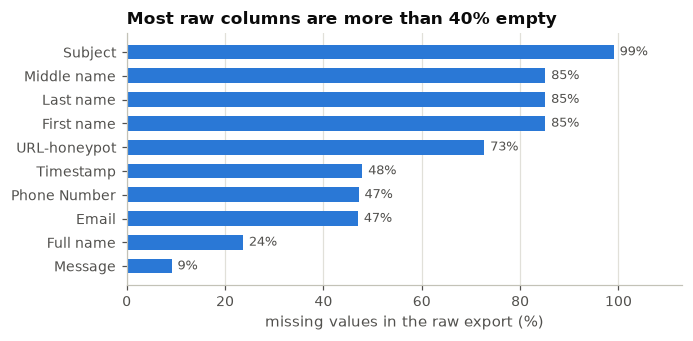

,step,rows,removed
0,1 raw rows,5766,0
1,2 after dropping rows with no content,5650,116
2,3 after dropping exact duplicates,5439,211


,count
raw rows,5766
rows after cleaning,5439
rows where First = Middle = Last name (redundant columns),702
rows with an empty message,404
rows whose message repeats another row's template,2317
distinct message templates,3122
rows with a recorded honeypot label,2856
of which honeypot filled,1573
of which honeypot left empty,1283
"rows with unknown label (older export, no timestamp)",2583


,rows by writing system
script,
latin,3953
cyrillic,790
none,520
other,176


In [4]:
raw_total = prep["steps"][0]["rows"]
missing = (pd.Series(prep["raw_missing"]) / raw_total * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6.4, 3.2))
barh(ax, missing.index, missing.values, fmt="{:.0f}%", xlabel="missing values in the raw export (%)")
ax.set_title("Most raw columns are more than 40% empty")
savefig("fig_missing_raw")

steps = pd.DataFrame(prep["steps"])
steps["removed"] = -steps["rows"].diff().fillna(0).astype(int)
display(steps)

known = df["honeypot_filled"].notna()
quality = pd.Series({
    "raw rows": raw_total,
    "rows after cleaning": len(df),
    "rows where First = Middle = Last name (redundant columns)": prep["redundant_name_rows"],
    "rows with an empty message": int((df["has_message"] == 0).sum()),
    "rows whose message repeats another row's template": int((df["template_count"] > 1).sum()),
    "distinct message templates": int(df.loc[df["template_id"] != "", "template_id"].nunique()),
    "rows with a recorded honeypot label": int(known.sum()),
    "  of which honeypot filled": int((df["honeypot_filled"] == 1).sum()),
    "  of which honeypot left empty": int((df["honeypot_filled"] == 0).sum()),
    "rows with unknown label (older export, no timestamp)": int((~known).sum()),
})
display(quality.to_frame("count"))
display(df["script"].value_counts().to_frame("rows by writing system"))
METRICS["data"] = {k.strip(): int(v) for k, v in quality.items()}
METRICS["data"]["script"] = df["script"].value_counts().to_dict()

In [5]:
# Noise: a few extreme values dominate the raw scale of the count features.
display(df[["msg_len", "word_count", "url_count", "name_len", "email_local_len"]]
        .describe(percentiles=[0.5, 0.95, 0.99]).T[["50%", "95%", "99%", "max"]])

,50%,95%,99%,max
msg_len,106.000,2247.400,6243.960,32734.000
word_count,18.000,337.200,988.020,4599.000
url_count,1.000,5.000,20.000,736.000
name_len,10.000,18.000,38.620,392.000
email_local_len,7.000,17.000,21.000,3034.000


**What the quality report shows**

- **Missing values.** Two exports were merged into the sheet. The older one has no timestamp and no honeypot
  column, which is why those two columns are about half empty. For those rows the honeypot label is *unknown*,
  not "not filled", so they are kept for unsupervised mining and left out of Task A.
- **Redundant attributes.** `First name`, `Middle name` and `Last name` hold the same string in most rows that
  have them. They were merged into one name before features were computed.
- **Duplicates.** Exact duplicate rows were removed. Repeated *templates* were kept and counted
  (`template_count`), because repetition is the signature of a campaign.
- **Noise.** The maximum message length sits at the 32,767-character limit of a spreadsheet cell, and some
  "names" are several hundred characters long because a bot pasted its message into the name field. The 99th
  percentile is far below the maximum for every count feature, so these features are log-transformed before
  any distance-based method (Section 2.5).

## 1.3 A data-quality finding: twelve months without a single honeypot hit

Checking the label before using it turned up one pattern that changes how it must be read. The timestamped
submissions are sorted by time and split into *runs* of consecutive submissions that left the honeypot empty.

In [6]:
stamped = df[df["timestamp"].notna()].sort_values(["timestamp", "id"])
empty = stamped["honeypot_filled"].eq(0).to_numpy()
run_id = np.cumsum(~empty)                                   # a new run starts after every filled submission
runs = (stamped[empty].groupby(run_id[empty])
        .agg(first=("timestamp", "min"), last=("timestamp", "max"), submissions=("id", "size"))
        .sort_values("submissions", ascending=False))
runs["days"] = (runs["last"] - runs["first"]).dt.days
display(runs.head(5).reset_index(drop=True))

in_window = df["id"].isin(set(stamped["id"][empty & (run_id == runs.index[0])])).to_numpy()
assert (in_window == df["honeypot_reliable"].eq(0).to_numpy()).all()    # the same rows are flagged in the dataset
win_start, win_end = runs["first"].iloc[0], runs["last"].iloc[0]

before = stamped[(stamped["timestamp"] < win_start) & (stamped["timestamp"] >= win_start - pd.Timedelta(days=90))]
after = stamped[(stamped["timestamp"] > win_end) & (stamped["timestamp"] <= win_end + pd.Timedelta(days=90))]
print(f"90 days before the run: {before['honeypot_filled'].mean():.0%} of {len(before)} submissions filled the honeypot")
print(f"inside the run:         0% of {int(in_window.sum())} submissions, {win_start:%d %b %Y} to {win_end:%d %b %Y}")
print(f"90 days after the run:  {after['honeypot_filled'].mean():.0%} of {len(after)} submissions filled the honeypot")

outside = df[~in_window & df["honeypot_filled"].notna() & (df["template_id"] != "")]
both = set(outside["template_id"]) & set(df.loc[in_window, "template_id"])
same_out = outside[outside["template_id"].isin(both)]
n_in = int((in_window & df["template_id"].isin(both).to_numpy()).sum())
p_out = float(same_out["honeypot_filled"].mean())
print(f"\n{len(both)} message templates occur both inside and outside the run. Outside it they fill the honeypot in "
      f"{p_out:.1%} of {len(same_out)} submissions; inside it in 0 of {n_in}.")
print(f"If their behaviour were unchanged, the chance of 0 hits in {n_in} submissions would be (1 - {p_out:.3f})^{n_in} = {(1 - p_out) ** n_in:.1e}")
print(f"share of submissions with an e-mail address: {before['has_email'].mean():.0%} before the run, "
      f"{df.loc[in_window, 'has_email'].mean():.0%} inside it, {after['has_email'].mean():.0%} after it")

df["honeypot_recorded"] = df["honeypot_filled"]              # the label exactly as exported
df.loc[in_window, "honeypot_filled"] = np.nan                # from here on: unknown inside the run
known = df["honeypot_filled"].notna()
label_counts = pd.Series({
    "label recorded": int(df["honeypot_recorded"].notna().sum()),
    "  inside the run, treated as unknown": int(in_window.sum()),
    "label used in this notebook": int(known.sum()),
    "  of which honeypot filled": int((df["honeypot_filled"] == 1).sum()),
    "  of which honeypot left empty": int((df["honeypot_filled"] == 0).sum()),
})
display(label_counts.to_frame("rows"))
METRICS["data"].update({k.strip(): int(v) for k, v in label_counts.items()})
METRICS["window"] = {"start": str(win_start), "end": str(win_end), "rows": int(in_window.sum()),
                     "days": int(runs["days"].iloc[0]), "second_longest_rows": int(runs["submissions"].iloc[1]),
                     "second_longest_days": int(runs["days"].iloc[1]),
                     "hit_rate_90d_before": float(before["honeypot_filled"].mean()),
                     "hit_rate_90d_after": float(after["honeypot_filled"].mean()),
                     "shared_templates": len(both), "shared_hit_rate_outside": p_out, "shared_rows_inside": n_in,
                     "chance_of_zero": float((1 - p_out) ** n_in)}

,first,last,submissions,days
0,2024-03-15 23:42:12,2025-03-10 15:20:38,647,359
1,2023-10-29 01:27:20,2023-11-02 00:03:12,98,3
2,2023-11-07 03:56:58,2023-11-09 15:17:49,52,2
3,2023-10-27 17:33:45,2023-10-29 00:27:20,34,1
4,2023-10-24 22:28:16,2023-10-26 11:49:05,32,1


90 days before the run: 32% of 157 submissions filled the honeypot
inside the run:         0% of 647 submissions, 15 Mar 2024 to 10 Mar 2025
90 days after the run:  96% of 278 submissions filled the honeypot

38 message templates occur both inside and outside the run. Outside it they fill the honeypot in 17.5% of 424 submissions; inside it in 0 of 195.
If their behaviour were unchanged, the chance of 0 hits in 195 submissions would be (1 - 0.175)^195 = 5.7e-17
share of submissions with an e-mail address: 100% before the run, 100% inside it, 61% after it


,rows
label recorded,2856
"inside the run, treated as unknown",647
label used in this notebook,2209
of which honeypot filled,1573
of which honeypot left empty,636


**Reading the evidence.**

- The longest run is about 650 submissions over a full year. The second longest is under 100 submissions in a
  few days, which is a burst of one campaign.
- In the three months before the run about a third of submissions filled the honeypot; in the three months
  after it almost all did. Inside it: none.
- Templates that appear on both sides of the boundary do fill the honeypot outside the run and never inside
  it. Under unchanged behaviour that outcome has a probability that is effectively zero.
- The contact fields change at the end of the run too (the share of submissions carrying an e-mail address
  drops), which points to a change of the form itself.

Every bot changing its behaviour on the same day, for exactly one year, is not a credible explanation. The
simplest one is that the honeypot field was not on the form during this period. The site's operator has
since confirmed it: **the form did not implement the honeypot at that time.**

**Decision.** Inside the run, "not filled" is read as "unknown". Those rows are real spam and stay in the
unsupervised analyses (similarity, clustering). They are left out of everything that uses the label: hit
rates, the association rules about the honeypot, and Task A. Section 8 also shows what Task A would have
reported had the recorded label been trusted. The dataset ships the recorded label together with a
`honeypot_reliable` flag, so that others can make their own choice.

# 2. Preprocessing

## 2.1 Handling missing values

| Situation | Decision | Reason |
| --- | --- | --- |
| Honeypot label unknown (older export) | Keep the row, treat it as unlabelled | Deleting it would throw away half of the campaign evidence; guessing a label would invent data |
| Empty message | Keep, with `has_message = 0` and text features set to 0 | An empty message is itself bot behaviour |
| Empty name / e-mail / phone | Keep, with a `has_*` indicator and length 0 | Which fields a bot skips is informative |
| Row with no content at all | Removed during preparation | Carries no information |

No value is imputed with a mean or a mode: for this data "missing" is a behaviour, not a measurement error.

## 2.2 Reducing redundant features

Features that carry the same information distort distance-based methods, because the shared information is
counted more than once. The correlation matrix shows which ones overlap.

,feature_a,feature_b,r
1261,has_email,email_valid,0.998
1266,has_email,has_phone,0.997
1307,email_valid,has_phone,0.994
1,msg_len,word_count,0.986
1345,email_local_len,email_local_digits,0.967
1555,phone_digits,phone_ru_format,0.959
127,line_count,url_count,0.924


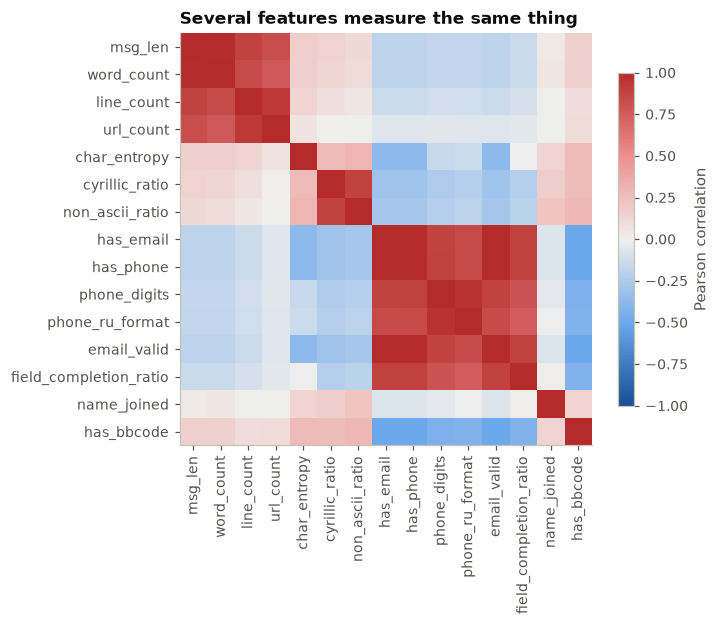

In [7]:
num = df[TEXT_F + CONTACT_F]
corr = num.corr()
pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
         .rename("r").reset_index().rename(columns={"level_0": "feature_a", "level_1": "feature_b"}))
redundant = pairs[pairs["r"].abs() >= 0.9].sort_values("r", key=abs, ascending=False)
display(redundant)

heat_cols = ["msg_len", "word_count", "line_count", "url_count", "char_entropy", "cyrillic_ratio", "non_ascii_ratio",
        "has_email", "has_phone", "phone_digits", "phone_ru_format", "email_valid", "field_completion_ratio",
        "name_joined", "has_bbcode"]
fig, ax = plt.subplots(figsize=(6.6, 5.6))
im = ax.imshow(corr.loc[heat_cols, heat_cols], cmap=DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(heat_cols)), heat_cols, rotation=90)
ax.set_yticks(range(len(heat_cols)), heat_cols)
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson correlation")
ax.set_title("Several features measure the same thing")
savefig("fig_correlation")

Pairs such as `has_email` / `email_valid` and `cyrillic_ratio` / `non_ascii_ratio` are near copies of each
other. They are not deleted by hand. Decision trees and Naive Bayes are run on the full set, and Section 6
(PCA) removes the redundancy for the methods that need it: KNN, the Mahalanobis classifier and clustering.

## 2.3 Feature creation

A raw message is text; the mining algorithms need numbers. Each feature below is created from the message.
Three of them are recomputed here from the published text and compared with the published columns, to show
exactly how they are defined.

In [8]:
URL_RE = re.compile(r"(?:https?://|www\.)[^\s<>\"'\[\]]+", re.I)
MASK_RE = re.compile(r"<(?:EMAIL|PHONE|SITE|NAME)>")


def shannon_entropy(text):
    """H = -sum p(c) log2 p(c) over the characters of the text."""
    if not text:
        return 0.0
    _, counts = np.unique(list(text), return_counts=True)
    p = counts / counts.sum()
    return float(-(p * np.log2(p)).sum())


recomputed = pd.DataFrame({
    "msg_len": df["message"].str.len(),
    "url_count": df["message"].map(lambda m: len(URL_RE.findall(m))),
    "char_entropy": df["message"].map(lambda m: shannon_entropy(MASK_RE.sub(" ", m).strip())),
})
agreement = {c: float(np.isclose(recomputed[c], df[c], atol=1e-6).mean()) for c in recomputed}
print("share of rows where the recomputed feature equals the published one:", agreement)
assert min(agreement.values()) > 0.99

example = df.loc[df["url_count"] > 0, ["message", "msg_len", "url_count", "char_entropy", "has_bbcode", "kw_money"]].head(3)
display(example.assign(message=example["message"].str[:80]))

share of rows where the recomputed feature equals the published one: {'msg_len': 1.0, 'url_count': 1.0, 'char_entropy': 1.0}


,message,msg_len,url_count,char_entropy,has_bbcode,kw_money
0,Здравствуйте! \n \nПредлагаем массовое размещение объявлений и товаров на Авито со,1043,2,4.918,0,0
1,Представляем удаленный отдел продаж http://topgrf.club \n \nМы можем найти вам мно,605,3,4.964,0,0
2,"Hеllо! \nIf you want to get ahead of your competition, have a higher Domain Autho",381,1,4.662,0,0


## 2.4 Discretization

Apriori (Section 5) and the information-gain calculation (Section 8) need categories, not continuous numbers.
Message length and URL count are cut into ordered bins with boundaries that have a plain meaning.

,rows,honeypot_rate
len_bin,,
empty,6,0.167
short (1-50),443,0.203
medium (51-300),1216,0.915
long (301-1000),445,0.665
very long (>1000),99,0.737


,rows,honeypot_rate
url_bin,,
no url,534,0.277
one url,1352,0.879
2+ urls,323,0.734


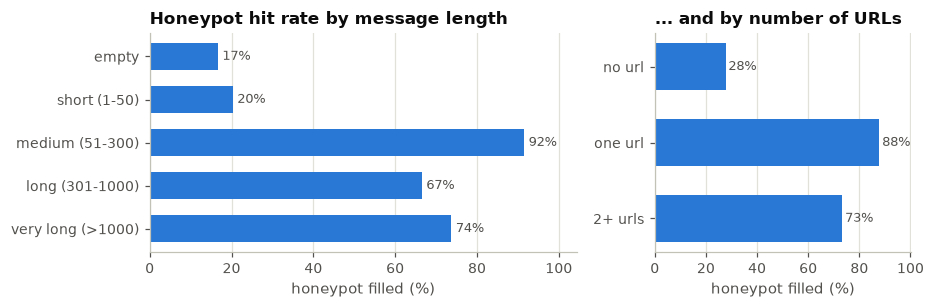

In [9]:
df["len_bin"] = pd.cut(df["msg_len"], [-1, 0, 50, 300, 1000, np.inf],
                       labels=["empty", "short (1-50)", "medium (51-300)", "long (301-1000)", "very long (>1000)"])
df["url_bin"] = pd.cut(df["url_count"], [-1, 0, 1, np.inf], labels=["no url", "one url", "2+ urls"])

by_len = df[known].groupby("len_bin", observed=True)["honeypot_filled"].agg(rows="size", honeypot_rate="mean")
by_url = df[known].groupby("url_bin", observed=True)["honeypot_filled"].agg(rows="size", honeypot_rate="mean")
display(by_len, by_url)

fig, axes = plt.subplots(1, 2, figsize=(8.6, 2.9), gridspec_kw={"width_ratios": [5, 3]})
barh(axes[0], by_len.index, by_len["honeypot_rate"] * 100, fmt="{:.0f}%", xlabel="honeypot filled (%)")
axes[0].set_title("Honeypot hit rate by message length")
barh(axes[1], by_url.index, by_url["honeypot_rate"] * 100, fmt="{:.0f}%", xlabel="honeypot filled (%)")
axes[1].set_title("... and by number of URLs")
savefig("fig_discretization")

## 2.5 Normalization and standardization

Features live on very different scales: message length reaches tens of thousands while ratios stay between
0 and 1. Any method built on distance (KNN, K-means, PCA) would be ruled by the largest scale.

- **Min-max normalization** maps a feature to [0, 1]: `x' = (x - min) / (max - min)`.
- **Standardization** gives mean 0 and standard deviation 1: `z = (x - mean) / std`.

The worked example uses five rows; the result is checked against scikit-learn.

In [10]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

sample = df.loc[df["has_message"] == 1, ["msg_len", "char_entropy"]].head(5).reset_index(drop=True)
by_hand = sample.copy()
for col in sample:
    x = sample[col]
    by_hand[col + "_minmax"] = (x - x.min()) / (x.max() - x.min())
    by_hand[col + "_z"] = (x - x.mean()) / x.std(ddof=0)
display(by_hand)
assert np.allclose(by_hand[["msg_len_minmax", "char_entropy_minmax"]], MinMaxScaler().fit_transform(sample))
assert np.allclose(by_hand[["msg_len_z", "char_entropy_z"]], StandardScaler().fit_transform(sample))
print("hand calculation matches MinMaxScaler and StandardScaler")

,msg_len,char_entropy,msg_len_minmax,msg_len_z,char_entropy_minmax,char_entropy_z
0,1043,4.918,1.000,1.004,0.626,0.031
1,605,4.964,0.338,-0.723,0.740,0.373
2,381,4.662,0.000,-1.606,0.000,-1.854
3,974,5.070,0.896,0.732,1.000,1.155
4,939,4.954,0.843,0.594,0.714,0.295


hand calculation matches MinMaxScaler and StandardScaler


Min-max normalization is sensitive to the extreme values found in Section 1.2: one 32,767-character message
would squeeze every other message into a sliver near 0. The count features are therefore first passed through
`log(1 + x)`, and the model matrix is then **standardized**. Scalers are always fitted on the training fold
only, inside a pipeline, so no information from the test fold leaks into training.

## 2.6 One-hot encoding

`script` is nominal. Coding it as 0, 1, 2, 3 would invent an order and a distance between writing systems,
so it becomes one binary column per value.

In [11]:
LOG_COLS = ["msg_len", "word_count", "avg_word_len", "line_count", "url_count", "email_mentions", "phone_mentions",
            "exclam_count", "name_len", "name_words", "email_local_len", "email_local_digits", "phone_digits"]
script_onehot = pd.get_dummies(df["script"], prefix="script").astype(int)
display(pd.concat([df["script"], script_onehot], axis=1).drop_duplicates("script"))

X_all = df[TEXT_F + CONTACT_F].astype(float).copy()
X_all[LOG_COLS] = np.log1p(X_all[LOG_COLS])
X_all = pd.concat([X_all, script_onehot], axis=1)
FEATURES = list(X_all.columns)
BINARY_F = [c for c in FEATURES if set(np.unique(X_all[c])) <= {0.0, 1.0}]
print(f"model matrix: {X_all.shape[0]:,} rows x {X_all.shape[1]} features ({len(BINARY_F)} binary)")
print("no time feature and nothing derived from the honeypot field is included")

,script,script_cyrillic,script_latin,script_none,script_other
0,cyrillic,1,0,0,0
2,latin,0,1,0,0
53,other,0,0,0,1
66,none,0,0,1,0


model matrix: 5,439 rows x 45 features (25 binary)
no time feature and nothing derived from the honeypot field is included


# 3. Distance and similarity

**What it is.** A number that says how alike two records are. **Type of learning.** None; these measures are
the building blocks of KNN, K-means, K-medoids and the Mahalanobis classifier. **Why it is needed here.**
Campaign discovery rests on one question, "is this message a variant of that one?", and that is a similarity
question.

## 3.1 Euclidean and Minkowski distance on numeric features

`d(x, y) = (sum |x_i - y_i|^r)^(1/r)`: r = 1 is Manhattan distance, r = 2 is Euclidean distance.

In [12]:
from scipy.spatial.distance import cdist


# ---- algorithms/distance.py ----
import numpy as np


def minkowski(a, b, r):
    return float((np.abs(a - b) ** r).sum() ** (1 / r))


def smc_jaccard(a, b):
    f11 = int(((a == 1) & (b == 1)).sum())
    f00 = int(((a == 0) & (b == 0)).sum())
    f10 = int(((a == 1) & (b == 0)).sum())
    f01 = int(((a == 0) & (b == 1)).sum())
    return (f11 + f00) / (f11 + f00 + f10 + f01), (f11 / (f11 + f10 + f01) if f11 + f10 + f01 else 0.0), (f11, f00, f10, f01)


Z_all = StandardScaler().fit_transform(X_all)
picks = df.index[df["has_message"] == 1][:5]
P = Z_all[picks]
labels5 = [f"id {i}" for i in df.loc[picks, "id"]]
for r, name in [(1, "Manhattan (r = 1)"), (2, "Euclidean (r = 2)"), (3, "Minkowski (r = 3)")]:
    D = np.array([[minkowski(a, b, r) for b in P] for a in P])
    assert np.allclose(D, cdist(P, P, "minkowski", p=r))
    print(name)
    display(pd.DataFrame(D, index=labels5, columns=labels5).round(2))

Manhattan (r = 1)


,id 1,id 2,id 3,id 4,id 5
id 1,0.000,10.210,30.810,3.510,32.670
id 2,10.210,0.000,31.780,7.820,35.060
id 3,30.810,31.780,0.000,29.570,13.650
id 4,3.510,7.820,29.570,0.000,31.340
id 5,32.670,35.060,13.650,31.340,0.000


Euclidean (r = 2)


,id 1,id 2,id 3,id 4,id 5
id 1,0.000,4.870,9.320,1.360,9.680
id 2,4.870,0.000,9.840,4.460,10.080
id 3,9.320,9.840,0.000,9.090,4.750
id 4,1.360,4.460,9.090,0.000,9.290
id 5,9.680,10.080,4.750,9.290,0.000


Minkowski (r = 3)


,id 1,id 2,id 3,id 4,id 5
id 1,0.000,4.350,6.700,1.100,6.800
id 2,4.350,0.000,7.050,4.210,7.070
id 3,6.700,7.050,0.000,6.590,3.610
id 4,1.100,4.210,6.590,0.000,6.610
id 5,6.800,7.070,3.610,6.610,0.000


## 3.2 Simple matching and Jaccard coefficients on binary features

For binary vectors, count the four kinds of match: f11 (both 1), f00 (both 0), f10 and f01.

- `SMC = (f11 + f00) / (f11 + f00 + f10 + f01)` counts shared absences as agreement.
- `Jaccard = f11 / (f11 + f10 + f01)` ignores shared absences.

The trait flags here are asymmetric (most are 0 for most rows), so two messages that both lack BBCode, crypto
words and pharmacy words are not thereby similar. Jaccard is the right measure; SMC is shown for contrast.

In [13]:
B = X_all.loc[picks, BINARY_F].to_numpy()
rows = []
for i, j in itertools.combinations(range(len(picks)), 2):
    smc, jac, (f11, f00, f10, f01) = smc_jaccard(B[i], B[j])
    rows.append({"pair": f"{labels5[i]} / {labels5[j]}", "f11": f11, "f00": f00, "f10": f10, "f01": f01,
                 "SMC": smc, "Jaccard": jac})
display(pd.DataFrame(rows))

,pair,f11,f00,f10,f01,SMC,Jaccard
0,id 1 / id 2,7,17,0,1,0.960,0.875
1,id 1 / id 3,5,16,2,2,0.840,0.556
2,id 1 / id 4,7,18,0,0,1.000,1.000
3,id 1 / id 5,5,16,2,2,0.840,0.556
4,id 2 / id 3,5,15,3,2,0.800,0.500
5,id 2 / id 4,7,17,1,0,0.960,0.875
6,id 2 / id 5,5,15,3,2,0.800,0.500
7,id 3 / id 4,5,16,2,2,0.840,0.556
8,id 3 / id 5,6,17,1,1,0.920,0.750
9,id 4 / id 5,5,16,2,2,0.840,0.556


SMC is high for every pair because most flags are 0 in both vectors. Jaccard separates the pairs.

## 3.3 Cosine similarity on text

Each message becomes a TF-IDF vector (one dimension per word, weighted up for words that are rare across
messages). `cos(x, y) = x . y / (|x| |y|)` measures the angle between two vectors and ignores their length,
so a short and a long version of the same advert still match.

3,122 distinct templates x 18,775 terms
cosine similarity of the first two templates, by hand and by scikit-learn: 0.1241


share of templates whose nearest other template is at least this similar: {'>= 0.5': 0.512, '>= 0.7': 0.332, '>= 0.9': 0.159}


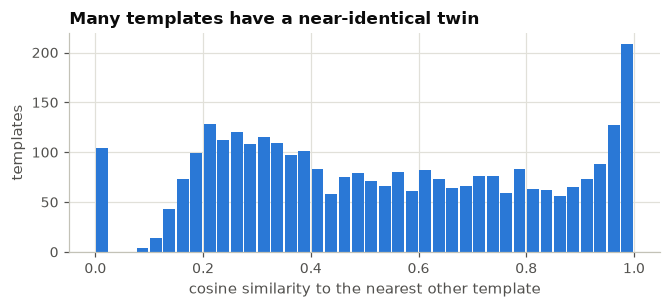

example near-duplicate pair, cosine = 0.96
 A: Здравствуйте!    Предлагаем массовое размещение объявлений и товаров на Авито со 100% гарантией от блокировки http://krdsprt.club    Авито сегодня — это крупней
 B: Здравствуйте!    Предлагаем массовое размещение ваших товаров и услуг на Авито, создание магазина на Авито со 100% гарантией от блокировки. Больше инфы на: http


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tpl = (df[df["has_message"] == 1].drop_duplicates("template_id")
       [["id", "template_id", "message", "script", "template_count"]].reset_index(drop=True))
tfidf = TfidfVectorizer(lowercase=True, min_df=2, max_features=20000, sublinear_tf=True)
T = tfidf.fit_transform(tpl["message"])
print(f"{len(tpl):,} distinct templates x {T.shape[1]:,} terms")

a, b = T[0].toarray().ravel(), T[1].toarray().ravel()
by_hand_cos = float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))
assert np.isclose(by_hand_cos, cosine_similarity(T[0], T[1])[0, 0])
print(f"cosine similarity of the first two templates, by hand and by scikit-learn: {by_hand_cos:.4f}")

# Nearest other template for every template (TF-IDF rows are already unit length, so T @ T.T is the cosine matrix).
S = (T @ T.T).toarray()
np.fill_diagonal(S, 0)
nearest = S.max(axis=1)
near_dup = {f">= {t}": float((nearest >= t).mean()) for t in (0.5, 0.7, 0.9)}
print("share of templates whose nearest other template is at least this similar:", {k: round(v, 3) for k, v in near_dup.items()})
METRICS["similarity"] = {"templates": int(len(tpl)), "near_duplicate_share": near_dup}

fig, ax = plt.subplots(figsize=(6.2, 2.9))
ax.hist(nearest, bins=40, color=C[0], rwidth=0.88)
ax.set_xlabel("cosine similarity to the nearest other template")
ax.set_ylabel("templates")
ax.set_title("Many templates have a near-identical twin")
savefig("fig_nearest_similarity")

i = int(np.argmax((nearest > 0.85) & (nearest < 0.97)))
j = int(S[i].argmax())
print(f"example near-duplicate pair, cosine = {S[i, j]:.2f}")
print(" A:", tpl.loc[i, "message"][:160].replace("\n", " "))
print(" B:", tpl.loc[j, "message"][:160].replace("\n", " "))

**Analysis.** Exact-template matching (Section 1.2) already found repeated messages. Cosine similarity shows
that many of the remaining "distinct" templates are small rewrites of one another: the histogram has a heavy
right side, and the example pair differs in only a few words. This is the evidence that campaigns exist beyond
exact copies, and it is why Section 7 clusters the templates.

# 4. OLAP: summarising five years of submissions

**What it is.** Online analytical processing stores pre-computed summaries of a fact table along several
dimensions (a *cube*) and answers questions by slicing, dicing, rolling up and drilling down.
**Type of learning.** None; this is descriptive analysis.
**Why it is needed here.** The operator's questions are of the form "how many, of what kind, when, and did the
honeypot catch them?". Those are aggregate questions over time, topic and language, not row lookups.

**Implementation.** The fact table has one row per timestamped submission. Dimensions: time
(year > quarter > month), part of day, script, topic (from the keyword flags). Measures: number of
submissions, number with a usable honeypot label, and number of honeypot hits; the hit rate is hits divided by
labelled submissions. The cube is computed once and every operation below reads the cube, never the raw rows.

In [15]:
fact = df[df["timestamp"].notna()].copy()
for col in ["year", "quarter", "month", "hour"]:
    fact[col] = fact[col].astype(int)
fact["topic"] = np.select(
    [fact["has_message"].eq(0), fact["kw_crypto"].eq(1), fact["kw_gambling"].eq(1), fact["kw_adult"].eq(1),
     fact["kw_pharma"].eq(1), fact["kw_seo"].eq(1), fact["kw_money"].eq(1)],
    ["no message", "crypto", "gambling", "adult", "pharma", "seo / marketing", "money"], default="other")

DIMS = ["year", "quarter", "month", "part_of_day", "script", "topic"]
MEASURES = ["submissions", "labelled", "honeypot_hits"]
cube = (fact.groupby(DIMS, observed=True)
        .agg(submissions=("id", "size"), labelled=("honeypot_filled", "count"), honeypot_hits=("honeypot_filled", "sum"))
        .reset_index())
print(f"fact table: {len(fact):,} rows  ->  cube: {len(cube):,} pre-computed cells over {len(DIMS)} dimensions")


def summarise(cells, by):
    """Aggregate cube cells to a coarser level and derive the hit rate."""
    out = cells.groupby(by, observed=True)[MEASURES].sum()
    out["hit_rate"] = out["honeypot_hits"] / out["labelled"].where(out["labelled"] > 0)
    return out


def olap_show(table):
    show(table, pct=["hit_rate"], ints=["honeypot_hits"])


def olap_dict(table):
    return {str(k): {"submissions": int(r.submissions), "labelled": int(r.labelled), "hit_rate": r.hit_rate}
            for k, r in table.iterrows()}

fact table: 2,856 rows  ->  cube: 672 pre-computed cells over 6 dimensions


## 4.1 Roll-up: month -> quarter -> year

Rolling up climbs the time hierarchy: detail is summed away and the long-term picture appears.

,submissions,labelled,honeypot_hits,hit_rate
year,,,,
2020,58,58,50,86.2%
2021,106,106,84,79.2%
2022,695,695,683,98.3%
2023,978,978,455,46.5%
2024,609,94,34,36.2%
2025,410,278,267,96.0%


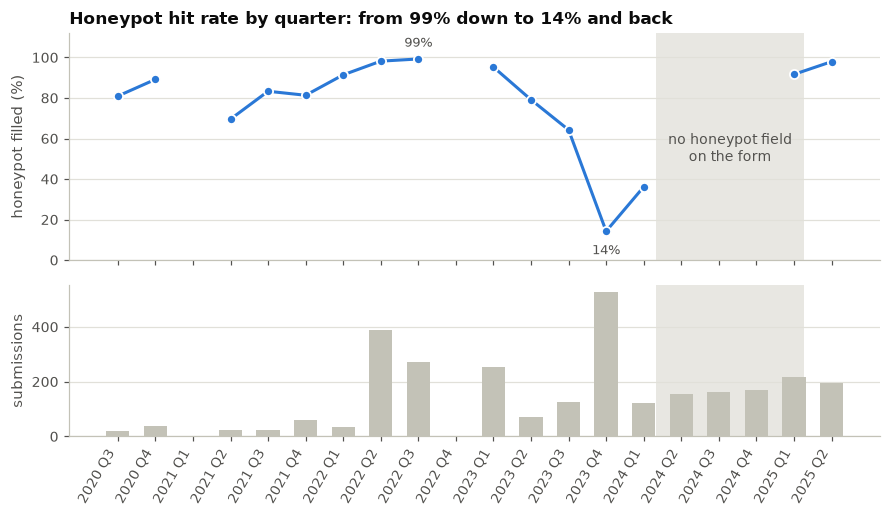

In [16]:
by_year = summarise(cube, ["year"])
olap_show(by_year)
METRICS["olap"] = {"by_year": olap_dict(by_year),
                   "overall_hit_rate": float(cube["honeypot_hits"].sum() / cube["labelled"].sum())}

by_quarter = summarise(cube, ["year", "quarter"])
full = pd.MultiIndex.from_product([range(by_quarter.index[0][0], by_quarter.index[-1][0] + 1), range(1, 5)],
                                  names=["year", "quarter"])
full = full[(full >= by_quarter.index[0]) & (full <= by_quarter.index[-1])]
q = by_quarter.reindex(full)                      # quarters with no export stay empty, they are not zero
q.loc[q["labelled"] < 20, "hit_rate"] = np.nan    # too few labelled rows for a rate
xlabels = [f"{y} Q{k}" for y, k in q.index]
x = np.arange(len(q))


def quarter_pos(ts):
    """Horizontal position of a date on the quarterly axis."""
    return list(q.index).index((ts.year, ts.quarter)) - 0.5 + ((ts.month - 1) % 3 + ts.day / 31) / 3


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.2, 4.8), sharex=True, gridspec_kw={"height_ratios": [3, 2]})
for ax in (ax1, ax2):
    ax.axvspan(quarter_pos(win_start), quarter_pos(win_end), color=GRID, alpha=0.75, linewidth=0, zorder=0)
ax1.text((quarter_pos(win_start) + quarter_pos(win_end)) / 2, 55, "no honeypot field\non the form", ha="center",
         va="center", fontsize=9, color=INK2)
ax1.plot(x, q["hit_rate"] * 100, color=C[0], marker="o")
hi, lo = int(np.nanargmax(q["hit_rate"])), int(np.nanargmin(q["hit_rate"]))
for pos, dy in ((hi, 8), (lo, -15)):
    ax1.annotate(f"{q['hit_rate'].iloc[pos]:.0%}", (pos, q["hit_rate"].iloc[pos] * 100), xytext=(0, dy),
                 textcoords="offset points", ha="center", fontsize=8.5, color=INK2)
ax1.set_ylim(0, 112)
ax1.set_ylabel("honeypot filled (%)")
ax1.set_title(f"Honeypot hit rate by quarter: from {q['hit_rate'].iloc[hi]:.0%} down to {q['hit_rate'].iloc[lo]:.0%} and back")
ax2.bar(x, q["submissions"].fillna(0), color=GRAY, width=0.62)
ax2.set_ylabel("submissions")
ax2.set_xticks(x, xlabels, rotation=60, ha="right")
ax2.grid(axis="x", visible=False)
ax1.grid(axis="x", visible=False)
savefig("fig_honeypot_rate")
METRICS["olap"]["by_quarter"] = olap_dict(by_quarter.rename(index=lambda v: str(v)))

## 4.2 Drill-down: year 2023 -> quarter -> month

Drilling down goes the other way: take the year in which the rate fell and open it up.

In [17]:
DRILL_YEAR = 2023
olap_show(summarise(cube[cube["year"] == DRILL_YEAR], ["year", "quarter"]))
drill_month = summarise(cube[cube["year"] == DRILL_YEAR], ["year", "quarter", "month"])
olap_show(drill_month)
METRICS["olap"]["drill_2023_by_month"] = {int(m): r.hit_rate for (_, _, m), r in drill_month.iterrows()}

submissions  labelled  honeypot_hits hit_rate
year quarter                                               
2023 1                254       254            242    95.3%
     2                 72        72             57    79.2%
     3                126       126             81    64.3%
     4                526       526             75    14.3%

submissions  labelled  honeypot_hits hit_rate
year quarter month                                               
2023 1       1              146       146            142    97.3%
             2               85        85             83    97.6%
             3               23        23             17    73.9%
     2       4               26        26             24    92.3%
             5               17        17             14    82.4%
             6               29        29             19    65.5%
     3       7               51        51             34    66.7%
             8               48        48             30    62.5%
             9               27        27             17    63.0%
     4       10             206       206             17     8.3%
             11             208       208             24    11.5%
             12             112       112             34    30.4%

## 4.3 Slice: fix one value of one dimension

A slice fixes a single value on one dimension and returns the remaining sub-cube. Here the time dimension is
fixed at the fourth quarter of 2023, where the drill-down found the lowest hit rate.

In [18]:
sl = cube[(cube["year"] == DRILL_YEAR) & (cube["quarter"] == 4)]
slice_topic = summarise(sl, ["topic"]).sort_values("submissions", ascending=False)
olap_show(slice_topic)
olap_show(summarise(sl, ["script"]).sort_values("submissions", ascending=False))
METRICS["olap"]["slice_2023_q4_by_topic"] = olap_dict(slice_topic)

,submissions,labelled,honeypot_hits,hit_rate
topic,,,,
other,398,398,41,10.3%
seo / marketing,56,56,15,26.8%
crypto,33,33,9,27.3%
money,19,19,6,31.6%
adult,8,8,1,12.5%
pharma,6,6,2,33.3%
no message,4,4,0,0.0%
gambling,2,2,1,50.0%


,submissions,labelled,honeypot_hits,hit_rate
script,,,,
latin,374,374,52,13.9%
cyrillic,54,54,7,13.0%
other,54,54,2,3.7%
none,44,44,14,31.8%


## 4.4 Dice: restrict several dimensions at once

A dice picks a set of values on two or more dimensions: the years 2022 and 2023, the two main scripts, and
messages that carry a topic keyword.

In [19]:
dice = cube[cube["year"].isin([2022, 2023]) & cube["script"].isin(["latin", "cyrillic"])
            & ~cube["topic"].isin(["no message", "other"])]
dice_tbl = summarise(dice, ["topic", "year", "script"])
display(dice_tbl["hit_rate"].unstack(["year", "script"]).apply(lambda col: col.map(lambda v: "-" if pd.isna(v) else f"{v:.0%}")))
display(dice_tbl["submissions"].unstack(["year", "script"], fill_value=0))

year                2022        2023         
script          cyrillic latin latin cyrillic
topic                                        
adult               100%  100%   30%        -
crypto                 -  100%   45%       0%
gambling               -  100%   75%       0%
money                  -   98%   89%        -
pharma                 -  100%   44%        -
seo / marketing     100%   96%   54%      88%

year                2022        2023         
script          cyrillic latin latin cyrillic
topic                                        
adult                  2     2    10        0
crypto                 0    13    47        1
gambling               0     1    12        1
money                  0   495   200        0
pharma                 0     7     9        0
seo / marketing        1    24   138        8

## 4.5 Which kind of spam does the honeypot miss?

In [20]:
by_topic = summarise(cube, ["topic"]).sort_values("submissions", ascending=False)
by_script = summarise(cube, ["script"]).sort_values("submissions", ascending=False)
by_part = summarise(cube, ["part_of_day"]).reindex(["night", "morning", "afternoon", "evening"])
olap_show(by_topic)
olap_show(by_script)
olap_show(by_part)
METRICS["olap"].update(by_topic=olap_dict(by_topic), by_script=olap_dict(by_script), by_part_of_day=olap_dict(by_part))

,submissions,labelled,honeypot_hits,hit_rate
topic,,,,
other,1252,884,454,51.4%
money,831,815,776,95.2%
seo / marketing,433,318,208,65.4%
no message,115,6,1,16.7%
crypto,95,88,56,63.6%
pharma,58,52,46,88.5%
gambling,39,23,17,73.9%
adult,33,23,15,65.2%


,submissions,labelled,honeypot_hits,hit_rate
script,,,,
latin,2377,1936,1461,75.5%
none,231,57,19,33.3%
cyrillic,174,154,86,55.8%
other,74,62,7,11.3%


,submissions,labelled,honeypot_hits,hit_rate
part_of_day,,,,
night,681,533,387,72.6%
morning,696,530,384,72.5%
afternoon,735,569,401,70.5%
evening,744,577,401,69.5%


**Analysis.**

- *Roll-up* gives the headline: the honeypot caught 79% to 98% of submissions from 2020 to 2022 and under half
  in 2023. The rate is not a constant of the form.
- *Drill-down* into 2023 shows when it fell: above 90% in the first months, about two thirds over the summer,
  and about 10% in October and November.
- *Slice.* In that quarter three quarters of the submissions carry none of the topic keywords, and only about
  one in ten of those fills the honeypot. The fall coincides with a wave of a different kind of message.
  The keyword topics are caught less often than before as well, on small counts.
- *Dice.* For the same topic and script the hit rate differs between 2022 and 2023, so the topic alone does
  not determine honeypot behaviour either.
- Submissions are spread evenly over the day, as expected of automated senders in many time zones.
- The shaded band is the window of Section 1.3, in which the form had no honeypot field. After it the rate is
  back above 90%. Gaps in the lower panel are months missing from the export, not months without spam.

This is the motivation for the rest of the notebook: the honeypot signal depends on who is sending and can
vanish altogether, so the *content* of a submission has to be mined.

# 5. Association rule mining with Apriori

**What it is.** A search for sets of items that occur together often (*frequent itemsets*) and for rules
`A -> B` between them. A rule is judged by **support** (how often A and B occur together), **confidence**
(how often B holds when A holds) and **lift** (confidence divided by the base rate of B; above 1 means A
makes B more likely).

**Type of learning.** Unsupervised: no label is given. The honeypot outcome enters as an ordinary item, so
rules that end in it can be read off afterwards.

**Why it is needed here.** The software's 14 rules were written by hand. Apriori produces rules of exactly
the same if-then shape from the data, with measured support and confidence instead of guessed weights.

**Implementation.** Each submission becomes a *transaction*: the set of traits it shows. The traits come from
the discretized (Section 2.4) and one-hot encoded (Section 2.6) attributes. Apriori is written from scratch
with the two steps from the lectures: *join* frequent (k-1)-itemsets into candidates of size k, and *prune*
any candidate that has an infrequent subset (the Apriori property: every subset of a frequent itemset is
frequent).

In [21]:
tx = fact[fact["honeypot_filled"].notna()]              # only submissions with a usable label
items = pd.DataFrame({
    "url=none": tx["url_count"].eq(0), "url=one": tx["url_count"].eq(1), "url=2+": tx["url_count"].ge(2),
    "len=empty": tx["msg_len"].eq(0), "len=short": tx["msg_len"].between(1, 50),
    "len=medium": tx["msg_len"].between(51, 300), "len=long": tx["msg_len"].gt(300),
    "script=latin": tx["script"].eq("latin"), "script=cyrillic": tx["script"].eq("cyrillic"),
    "markup=bbcode/html": tx["has_bbcode"].eq(1) | tx["has_html"].eq(1),
    "name=joined": tx["name_joined"].eq(1),
    "email=free": tx["email_free"].eq(1), "email=ru": tx["email_ru"].eq(1), "email=none": tx["has_email"].eq(0),
    "phone=ru_format": tx["phone_ru_format"].eq(1), "phone=none": tx["has_phone"].eq(0),
    "topic=money": tx["kw_money"].eq(1), "topic=seo": tx["kw_seo"].eq(1), "topic=crypto": tx["kw_crypto"].eq(1),
    "honeypot=filled": tx["honeypot_filled"].eq(1), "honeypot=empty": tx["honeypot_filled"].eq(0),
}).reset_index(drop=True)
ITEM = list(items.columns)
M = items.to_numpy()
print(f"{len(items):,} transactions x {len(ITEM)} items; average items per transaction: {M.sum(axis=1).mean():.1f}")
display(items.mean().sort_values(ascending=False).to_frame("support of single item").T.round(2))

2,209 transactions x 21 items; average items per transaction: 6.6


,script=latin,phone=ru_format,honeypot=filled,email=free,url=one,len=medium,topic=money,honeypot=empty,name=joined,len=long,url=none,len=short,topic=seo,url=2+,markup=bbcode/html,email=ru,script=cyrillic,phone=none,email=none,topic=crypto,len=empty
support of single item,0.880,0.830,0.710,0.660,0.610,0.550,0.440,0.290,0.250,0.250,0.240,0.200,0.160,0.150,0.100,0.080,0.070,0.050,0.050,0.040,0.000


In [22]:
# ---- algorithms/apriori.py ----
import itertools

import numpy as np
import pandas as pd


def apriori(M, min_support):
    """Frequent itemsets of a boolean transaction matrix: {frozenset(item indices): support}."""
    support = {}
    level = []
    for j in range(M.shape[1]):                                   # L1
        s = M[:, j].mean()
        if s >= min_support:
            support[frozenset([j])] = s
            level.append(frozenset([j]))
    k = 2
    while level:
        prev = set(level)
        candidates = {a | b for a in level for b in level if len(a | b) == k}                     # join
        candidates = [c for c in candidates
                      if all(frozenset(sub) in prev for sub in itertools.combinations(c, k - 1))]  # prune
        level = []
        for c in candidates:
            s = M[:, sorted(c)].all(axis=1).mean()                # one pass over the transactions
            if s >= min_support:
                support[c] = s
                level.append(c)
        k += 1
    return support


def make_rules(support, min_confidence):
    """All rules A -> B with A and B a split of a frequent itemset."""
    rows = []
    for itemset, s in support.items():
        for r in range(1, len(itemset)):
            for ante in map(frozenset, itertools.combinations(itemset, r)):
                cons = itemset - ante
                conf = s / support[ante]
                if conf >= min_confidence:
                    rows.append({"antecedent": ante, "consequent": cons, "support": s, "confidence": conf,
                                 "lift": conf / support[cons]})
    return pd.DataFrame(rows)


def names(itemset):
    return ", ".join(ITEM[j] for j in sorted(itemset))


MIN_SUP, MIN_CONF = 0.10, 0.80
freq = apriori(M, MIN_SUP)
rules = make_rules(freq, MIN_CONF)
by_size = pd.Series([len(s) for s in freq]).value_counts().sort_index()
print(f"min support {MIN_SUP}, min confidence {MIN_CONF}: {len(freq)} frequent itemsets, {len(rules)} rules")
display(by_size.to_frame("frequent itemsets").rename_axis("itemset size").T)

# Worked check of one rule, as in the lectures: support and confidence counted directly from the transactions.
A, Bc = ["url=one", "len=medium", "topic=money"], ["honeypot=filled"]
n_ab = int(items[A + Bc].all(axis=1).sum())
n_a = int(items[A].all(axis=1).sum())
print(f"rule {{{', '.join(A)}}} -> {{{Bc[0]}}}: support = {n_ab}/{len(items)} = {n_ab / len(items):.3f}, "
      f"confidence = {n_ab}/{n_a} = {n_ab / n_a:.3f}, lift = {(n_ab / n_a) / items[Bc[0]].mean():.2f}")

min support 0.1, min confidence 0.8: 281 frequent itemsets, 1183 rules


itemset size,1,2,3,4,5,6,7
frequent itemsets,15,52,82,74,42,14,2


rule {url=one, len=medium, topic=money} -> {honeypot=filled}: support = 744/2209 = 0.337, confidence = 744/771 = 0.965, lift = 1.36


In [23]:
# Cross-check the frequent itemsets against mlxtend.
try:
    from mlxtend.frequent_patterns import apriori as mlx_apriori
    ref = mlx_apriori(items, min_support=MIN_SUP, use_colnames=True)
    ref_support = {frozenset(ITEM.index(i) for i in s): v for s, v in zip(ref["itemsets"], ref["support"])}
    assert set(ref_support) == set(freq) and all(np.isclose(freq[s], ref_support[s]) for s in freq)
    print(f"from-scratch Apriori and mlxtend agree on all {len(freq)} frequent itemsets and their supports")
except ImportError:
    print("mlxtend is not installed; cross-check skipped (pip install mlxtend)")

from-scratch Apriori and mlxtend agree on all 281 frequent itemsets and their supports


In [24]:
# Sensitivity: how the output grows when the thresholds are relaxed.
grid = []
for sup in (0.05, 0.10, 0.20, 0.30):
    fs = apriori(M, sup)
    row = {"min support": sup, "frequent itemsets": len(fs), "largest itemset": max(map(len, fs))}
    for conf in (0.6, 0.8, 0.9):
        row[f"rules at confidence {conf}"] = len(make_rules(fs, conf))
    grid.append(row)
sensitivity = pd.DataFrame(grid)
display(sensitivity)

,min support,frequent itemsets,largest itemset,rules at confidence 0.6,rules at confidence 0.8,rules at confidence 0.9
0,0.050,399,7,2743,1281,666
1,0.100,281,7,2440,1183,604
2,0.200,140,7,1116,532,254
3,0.300,85,5,508,271,121


In [25]:
HP = {ITEM.index("honeypot=filled"), ITEM.index("honeypot=empty")}


def honeypot_rules(target, keep=6):
    """Rules ending in one honeypot outcome. A longer rule is listed only if its extra items raise confidence."""
    t = frozenset([ITEM.index(target)])
    sel = rules[(rules["consequent"] == t) & rules["antecedent"].map(lambda a: not (a & HP))].copy()
    sel["size"] = sel["antecedent"].map(len)
    kept = []
    for r in sel.sort_values(["size", "confidence"], ascending=[True, False]).itertuples():
        if not any(k.antecedent < r.antecedent and k.confidence >= r.confidence - 0.02 for k in kept):
            kept.append(r)
    out = pd.DataFrame([{"antecedent": names(r.antecedent), "consequent": target, "support": r.support,
                         "confidence": r.confidence, "lift": r.lift} for r in kept])
    return out.sort_values(["lift", "support"], ascending=False).head(keep).reset_index(drop=True)


top_filled, top_empty = honeypot_rules("honeypot=filled"), honeypot_rules("honeypot=empty")
print("rules that predict the honeypot is FILLED (base rate {:.2f})".format(items["honeypot=filled"].mean()))
display(top_filled)
print("rules that predict the honeypot is left EMPTY (base rate {:.2f})".format(items["honeypot=empty"].mean()))
display(top_empty)

METRICS["apriori"] = {
    "transactions": int(len(items)), "items": len(ITEM), "min_support": MIN_SUP, "min_confidence": MIN_CONF,
    "frequent_itemsets": int(len(freq)), "rules": int(len(rules)),
    "sensitivity": sensitivity.to_dict("records"),
    "top_filled": top_filled.to_dict("records"), "top_empty": top_empty.to_dict("records"),
}

rules that predict the honeypot is FILLED (base rate 0.71)


,antecedent,consequent,support,confidence,lift
0,"len=medium, topic=money",honeypot=filled,0.339,0.961,1.350
1,"url=one, len=medium, script=latin, phone=ru_format",honeypot=filled,0.402,0.938,1.317
2,"url=one, len=medium, email=free, phone=ru_format",honeypot=filled,0.272,0.938,1.317
3,"len=medium, script=latin, email=free, phone=ru_format",honeypot=filled,0.276,0.936,1.314
4,"url=one, topic=money",honeypot=filled,0.354,0.921,1.293
5,len=medium,honeypot=filled,0.504,0.915,1.285


rules that predict the honeypot is left EMPTY (base rate 0.29)


,antecedent,consequent,support,confidence,lift
0,"url=none, len=short, email=free, phone=ru_format",honeypot=empty,0.140,0.878,3.050
1,"len=short, name=joined",honeypot=empty,0.143,0.877,3.048
2,"url=none, name=joined",honeypot=empty,0.146,0.863,2.998
3,"len=short, email=free",honeypot=empty,0.141,0.857,2.977
4,"url=none, len=short, script=latin",honeypot=empty,0.104,0.839,2.916
5,"len=short, phone=ru_format",honeypot=empty,0.144,0.833,2.893


**Analysis.**

- *Thresholds.* The sensitivity table shows the usual trade-off: lowering the support threshold multiplies the
  number of itemsets and rules. Support 0.10 and confidence 0.80 keep the rule list short enough to read while
  every rule still covers at least a tenth of the submissions.
- *Rules ending in "honeypot filled".* A medium-length message about money fills the honeypot in about 96% of
  cases, against a base rate of 71%. Reading the matching rows shows one campaign behind this rule: the
  "financial robot" adverts. That bot completes every field it finds, hidden ones included.
- *Rules ending in "honeypot empty".* A short message sent under a joined name such as `CarlosSob` leaves the
  honeypot empty about 88% of the time, three times the base rate of 29%. The matching rows are a single
  sentence, "Hi, I wanted to know your price", machine-translated into dozens of languages. This sender fills
  name, e-mail, phone and message correctly and skips the hidden field, so the honeypot does not see it.
- *What the rules do not show.* A rule reports co-occurrence in the data it was mined from, not cause. The two
  campaigns were active in different periods (Section 4), so part of each rule is that time effect, and
  Section 8 shows the one-line enquiry behaving differently in 2025.
- *Use in the software.* Each rule has the shape of a FormTrap scoring rule and can be shown to the operator
  with its measured confidence in place of a hand-picked weight.

# 6. Dimensionality reduction with PCA

**What it is.** Principal component analysis finds new axes (principal components) that are uncorrelated and
ordered by how much of the data's variance they carry. Keeping the first few components keeps most of the
information in fewer dimensions.

**Type of learning.** Unsupervised: the labels are not used.

**Why it is needed here.** Section 2.2 showed groups of features that say the same thing. Redundant features
(1) are counted several times in every distance, which hurts KNN and K-means, (2) make the covariance matrix
singular, so it cannot be inverted for the Mahalanobis classifier, and (3) cannot be plotted in two
dimensions.

**Implementation.** The five steps from the lectures: centre the data, compute the covariance matrix, find its
eigenvalues, find the eigenvectors, project. First on two features by hand, then on the full matrix, checked
against scikit-learn.

In [26]:
# Worked example with two correlated features and six messages.
small = X_all.loc[df["has_message"] == 1, ["msg_len", "word_count"]].iloc[[0, 5, 9, 14, 20, 40]].to_numpy()
mean = small.mean(axis=0)                                     # step 1: feature means, then centre
centred = small - mean
cov = centred.T @ centred / (len(small) - 1)                  # step 2: covariance matrix
a_, b_, d_ = cov[0, 0], cov[0, 1], cov[1, 1]
lam1 = ((a_ + d_) + math.sqrt((a_ - d_) ** 2 + 4 * b_ ** 2)) / 2    # step 3: roots of det(cov - lambda I) = 0
lam2 = ((a_ + d_) - math.sqrt((a_ - d_) ** 2 + 4 * b_ ** 2)) / 2
v1 = np.array([b_, lam1 - a_])                                # step 4: solve (cov - lambda1 I) v = 0, then normalize
v1 = v1 / np.linalg.norm(v1)
pc1 = centred @ v1                                            # step 5: project every row on PC 1
print("covariance matrix:\n", cov.round(4))
print(f"eigenvalues: {lam1:.4f}, {lam2:.4f}  ->  PC 1 keeps {lam1 / (lam1 + lam2):.1%} of the variance")
print("first eigenvector:", v1.round(4))
print("2-D data becomes 1-D:", pc1.round(3))
assert np.allclose(sorted([lam1, lam2]), np.linalg.eigvalsh(cov))

covariance matrix:
 [[0.155  0.161 ]
 [0.161  0.1706]]
eigenvalues: 0.3240, 0.0015  ->  PC 1 keeps 99.5% of the variance
first eigenvector: [0.6898 0.724 ]
2-D data becomes 1-D: [ 0.404  0.717  0.154  0.014 -0.433 -0.855]


from-scratch PCA matches scikit-learn. 45 features -> 21 components keep 90% of the variance, 25 keep 95%; the last 2 eigenvalue(s) are zero (exact redundancy)


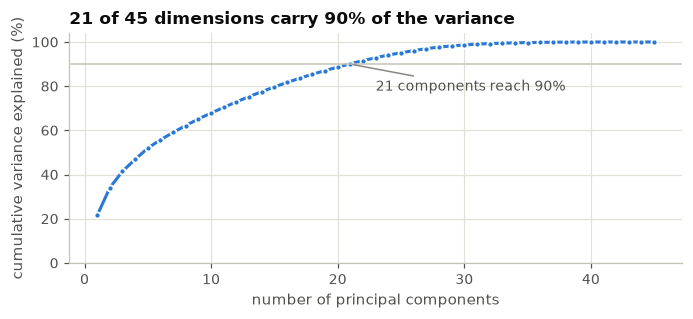

In [27]:
from sklearn.decomposition import PCA


# ---- algorithms/pca.py ----
import numpy as np


def pca_scratch(Z):
    """Eigen-decomposition of the covariance matrix. Returns eigenvalues, eigenvectors (columns) and scores."""
    Zc = Z - Z.mean(axis=0)
    cov = Zc.T @ Zc / (len(Z) - 1)
    values, vectors = np.linalg.eigh(cov)
    order = np.argsort(values)[::-1]
    values, vectors = values[order], vectors[:, order]
    return values, vectors, Zc @ vectors


eigvals, eigvecs, scores = pca_scratch(Z_all)
ratio = eigvals / eigvals.sum()
cum = np.cumsum(ratio)
pca_ref = PCA().fit(Z_all)
assert np.allclose(eigvals, pca_ref.explained_variance_, atol=1e-8)
assert np.allclose(np.abs(eigvecs[:, :5].T), np.abs(pca_ref.components_[:5]), atol=1e-6)
N90, N95 = int(np.searchsorted(cum, 0.90) + 1), int(np.searchsorted(cum, 0.95) + 1)
print(f"from-scratch PCA matches scikit-learn. {Z_all.shape[1]} features -> {N90} components keep 90% of the "
      f"variance, {N95} keep 95%; the last {int((eigvals < 1e-8).sum())} eigenvalue(s) are zero (exact redundancy)")
METRICS["pca"] = {"features": int(Z_all.shape[1]), "components_90": N90, "components_95": N95,
                  "pc1_ratio": float(ratio[0]), "pc2_ratio": float(ratio[1])}

fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(range(1, len(cum) + 1), cum * 100, color=C[0], marker="o", markersize=4)
ax.axhline(90, color=AXIS, linewidth=1)
ax.annotate(f"{N90} components reach 90%", (N90, 90), xytext=(N90 + 2, 78), fontsize=9, color=INK2,
            arrowprops={"arrowstyle": "-", "color": MUTED})
ax.set_xlabel("number of principal components")
ax.set_ylabel("cumulative variance explained (%)")
ax.set_ylim(0, 104)
ax.set_title(f"{N90} of {Z_all.shape[1]} dimensions carry 90% of the variance")
savefig("fig_pca_variance")

PC1 (21.5% of variance), strongest loadings:
   has_phone (+0.28), has_email (+0.28), email_valid (+0.28), email_local_len (+0.28), phone_digits (+0.24), msg_len (-0.24), word_count (-0.23)
PC2 (12.5% of variance), strongest loadings:
   field_completion_ratio (-0.29), script_none (+0.28), script_latin (-0.26), avg_word_len (-0.25), char_entropy (-0.25), has_name (-0.24), name_len (-0.23)


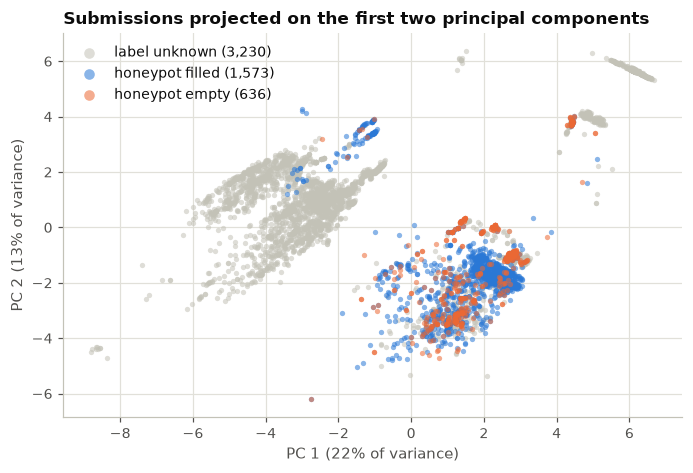

In [28]:
loadings = pd.DataFrame(eigvecs[:, :2], index=FEATURES, columns=["PC1", "PC2"])
for pc in ["PC1", "PC2"]:
    top = loadings[pc].reindex(loadings[pc].abs().sort_values(ascending=False).index).head(7)
    print(f"{pc} ({ratio[int(pc[2]) - 1]:.1%} of variance), strongest loadings:")
    print("   " + ", ".join(f"{f} ({v:+.2f})" for f, v in top.items()))

status = df["honeypot_filled"].map({1.0: "honeypot filled", 0.0: "honeypot empty"}).fillna("label unknown")
fig, ax = plt.subplots(figsize=(6.4, 4.4))
for name, colour, z in [("label unknown", GRAY, 1), ("honeypot filled", C[0], 2), ("honeypot empty", C[1], 3)]:
    m = (status == name).to_numpy()
    ax.scatter(scores[m, 0], scores[m, 1], s=12, color=colour, alpha=0.55, linewidths=0, label=f"{name} ({m.sum():,})", zorder=z)
ax.set_xlabel(f"PC 1 ({ratio[0]:.0%} of variance)")
ax.set_ylabel(f"PC 2 ({ratio[1]:.0%} of variance)")
ax.legend(loc="best", markerscale=2)
ax.set_title("Submissions projected on the first two principal components")
savefig("fig_pca_scatter")

**Analysis.**

- The eigenvalue curve confirms the redundancy seen in the correlation matrix: far fewer components than
  features are needed for 90% of the variance, and the smallest eigenvalue is zero because the one-hot script
  columns always sum to 1.
- The loadings give the components a meaning. PC 1 is dominated by the contact-field features (whether an
  e-mail and phone were given), with message length pulling the other way: it separates "contact fields
  filled, short message" from "contact fields empty, long message". PC 2 contrasts submissions that carry an
  ordinary Latin-script message and a name with submissions that have no readable text.
- In the projection the two honeypot outcomes occupy different regions but overlap, so the label is
  learnable from these features and not trivially so. Section 8 measures how well.
- PCA is used below wherever a method needs uncorrelated, non-redundant inputs: the Mahalanobis classifier
  and the Gaussian mixture. Section 8.5 also measures what PCA does to KNN and logistic regression.

# 7. Clustering: discovering spam campaigns

**Type of learning.** Unsupervised. No campaign labels exist; the algorithms group messages by similarity
alone.

**Why it is needed here.** Section 3.3 showed that many templates are rewrites of one another. Grouping them
lets an operator review a handful of campaigns instead of thousands of messages, and lets the software tell a
new submission "you belong to campaign X".

**Representation.** Each distinct template is a TF-IDF vector. Common English words and URL fragments
(`https`, `com`, ...) are removed so that clusters form around content words. The vectors are reduced to 50
dimensions by truncated SVD (the sparse-matrix relative of PCA, known as latent semantic analysis) and scaled
to unit length, so that Euclidean distance between them orders pairs the same way cosine similarity does.

In [29]:
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import Normalizer

STOP = sorted(ENGLISH_STOP_WORDS | {"https", "http", "www", "com", "href", "url", "html", "htm", "php", "ru",
                                    "net", "org", "email", "phone", "site", "name"})
tfidf_c = TfidfVectorizer(lowercase=True, min_df=3, max_df=0.4, max_features=20000, sublinear_tf=True,
                          stop_words=STOP, token_pattern=r"(?u)\b[^\W\d_]{2,}\b")
Tc_all = tfidf_c.fit_transform(tpl["message"])
has_vocab = np.asarray(Tc_all.getnnz(axis=1) > 0).ravel()
ct = tpl[has_vocab].reset_index(drop=True)            # templates that share vocabulary with others
Tc = Tc_all[has_vocab]
lsa = make_pipeline(TruncatedSVD(50, random_state=SEED), Normalizer())
L = lsa.fit_transform(Tc)
terms_c = np.array(tfidf_c.get_feature_names_out())
no_vocab = tpl[~has_vocab]
print(f"{len(ct):,} templates x {Tc.shape[1]:,} terms -> {L.shape[1]} LSA dimensions")
print(f"{len(no_vocab)} templates share no vocabulary with any other template and are kept as their own group; examples:")
for msg in no_vocab["message"].head(4):
    print("   ", msg[:70].replace("\n", " "))

2,983 templates x 10,992 terms -> 50 LSA dimensions
139 templates share no vocabulary with any other template and are kept as their own group; examples:
    <a href=http://zrenieblog.ru/>Detail</a>:  <a href=http://zrenieblog.r
    yoo
    <NAME>
    Goodman http://pikabu.ru


## 7.1 K-means

**What it is.** Choose k centroids; assign every point to its nearest centroid; move each centroid to the mean
of its points; repeat until nothing changes. It minimises the sum of squared distances (SSE) from points to
their centroid.

**Implementation.** From scratch on a sample of 500 templates with k = 4, then checked against scikit-learn
started from the same initial centroids.

In [30]:
# ---- algorithms/kmeans.py ----
import numpy as np


def kmeans_scratch(X, centroids, max_iter=100):
    history = []
    for _ in range(max_iter):
        d = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)        # squared distance to every centroid
        labels = d.argmin(axis=1)                                             # assignment step
        history.append(float(d[np.arange(len(X)), labels].sum()))             # SSE
        new = np.array([X[labels == j].mean(axis=0) if (labels == j).any() else centroids[j]
                        for j in range(len(centroids))])                      # update step
        if np.allclose(new, centroids):
            break
        centroids = new
    return labels, centroids, history


rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(L), 500, replace=False)
Xs = L[sample_idx]
init = Xs[rng.choice(len(Xs), 4, replace=False)]
labels_s, cent_s, sse_hist = kmeans_scratch(Xs, init)
ref = KMeans(4, init=init, n_init=1, algorithm="lloyd", tol=0, max_iter=100).fit(Xs)
print("SSE per iteration:", [round(v, 2) for v in sse_hist])
print(f"converged after {len(sse_hist)} iterations; agreement with scikit-learn (adjusted Rand index): "
      f"{adjusted_rand_score(labels_s, ref.labels_):.3f}")
assert adjusted_rand_score(labels_s, ref.labels_) > 0.99

SSE per iteration: [667.66, 406.27, 392.07, 385.79, 384.11, 383.72, 383.49, 383.4, 383.33, 383.27, 383.21, 383.19]
converged after 12 iterations; agreement with scikit-learn (adjusted Rand index): 1.000


### Choosing k

Two diagnostics are computed for each k: the **SSE** (the "elbow" plot) and the **silhouette coefficient**,
which compares each point's distance to its own cluster with its distance to the nearest other cluster
(1 = compact and separate, 0 = overlapping).

,k,SSE,silhouette
0,4,2234.597,0.183
1,6,2112.961,0.181
2,8,2003.528,0.203
3,10,1918.143,0.235
4,12,1818.054,0.237
5,14,1764.027,0.246
6,16,1679.144,0.263


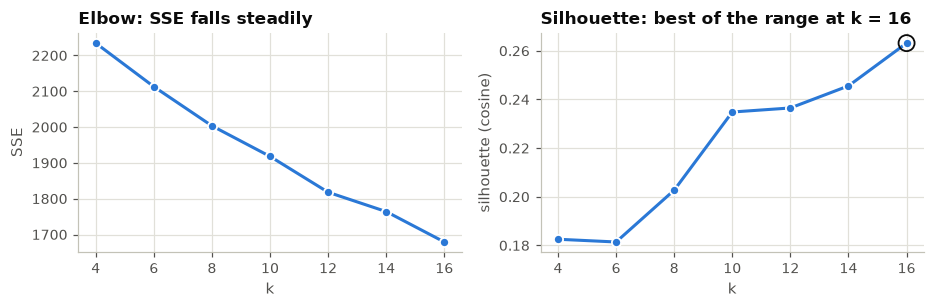

In [31]:
K_RANGE = list(range(4, 17, 2))
k_scan = []
for k in K_RANGE:
    km = KMeans(k, n_init=10, random_state=SEED).fit(L)
    k_scan.append({"k": k, "SSE": km.inertia_, "silhouette": silhouette_score(L, km.labels_, metric="cosine")})
k_scan = pd.DataFrame(k_scan)
display(k_scan)
K = int(k_scan.loc[k_scan["silhouette"].idxmax(), "k"])

fig, axes = plt.subplots(1, 2, figsize=(8.6, 2.9))
axes[0].plot(k_scan["k"], k_scan["SSE"], color=C[0], marker="o")
axes[0].set_title("Elbow: SSE falls steadily")
axes[0].set_xlabel("k")
axes[0].set_ylabel("SSE")
axes[1].plot(k_scan["k"], k_scan["silhouette"], color=C[0], marker="o")
axes[1].scatter([K], [k_scan["silhouette"].max()], s=110, facecolors="none", edgecolors=INK, linewidths=1.2, zorder=5)
axes[1].set_title(f"Silhouette: best of the range at k = {K}")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette (cosine)")
savefig("fig_kmeans_k")

,campaign,label,templates,submissions,honeypot_rate,main_script,first_year,last_year,example
0,10,"wek, gotodate, promo",149,854,97.8%,latin,2020,2025,"Salut, ech wollt Äre Präis wëssen. Make $1000 from $1 in a few minutes. Launch the fin..."
1,5,"google, hello, cc",472,660,61.3%,latin,2020,2025,<a href=https://pint77.blogspot.com/2023/10/stylish-and-modern-cat-furniture.html>Blog...
2,1,"hi, website, backlinks",289,579,56.5%,latin,2020,2025,"Hi, One of the less known websites where you can find not only a lot of Photography..."
3,3,"на, для, по",438,552,54.8%,cyrillic,2020,2025,"Интернет-магазины стали неотъемлемой частью современной жизни, предлагая покупателям у..."
4,4,"business, best, new",389,449,65.0%,latin,2020,2025,The advantages of using an Accounting company or accounting Firm for a lawyer and a ge...
5,-1,short / no shared vocabulary,139,446,23.7%,latin,2020,2025,<a href=http://zrenieblog.ru/>Detail</a>: <a href=http://zrenieblog.ru/>http://zrenie...
6,7,"click, unsubscribe, just",302,355,63.0%,latin,2020,2025,"Hey, Every business owner needs ultra fast loading websites to convert random website..."
7,6,"online, casino, games",145,195,74.2%,latin,2021,2025,we're revolutionizing the online gambling industry with our user-friendly platform and...
8,13,"seo, digital, ranks",107,157,64.0%,latin,2020,2025,"Hi, Worried about hidden SEO issues on your website? Let us help — completely free. ..."
9,0,"cialis, viagra, prescription",78,151,52.3%,latin,2022,2025,"Hallo, ek wou jou prys ken. <a href=""https://cialis20mgtab.monster/"">buy cialis brand ..."


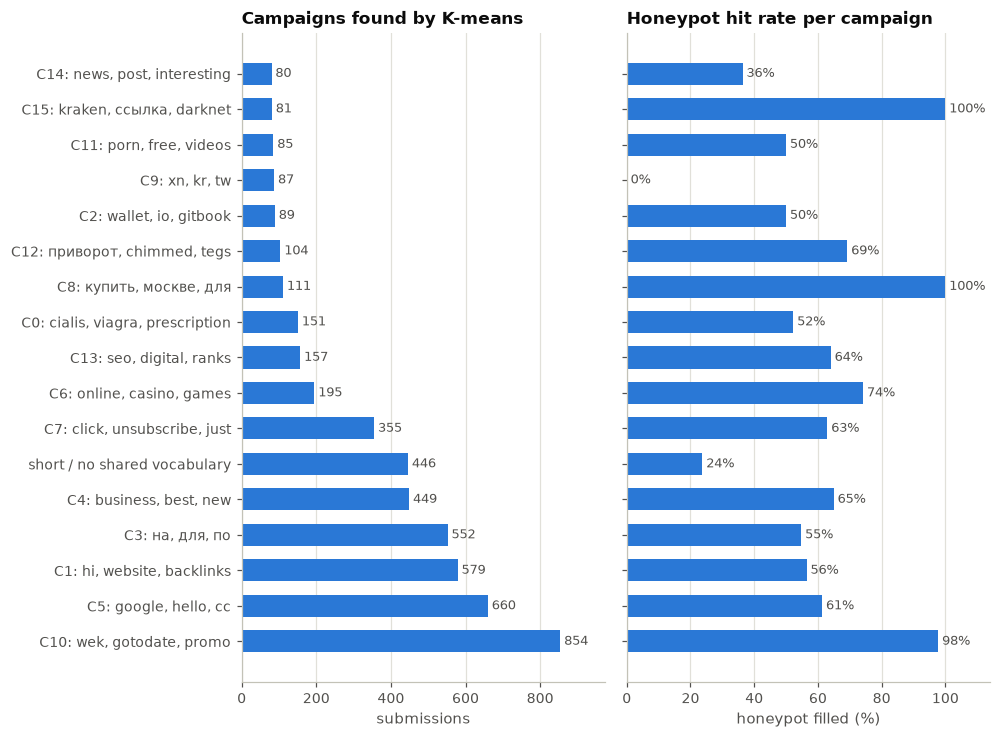

In [32]:
kmeans = KMeans(K, n_init=10, random_state=SEED).fit(L)
ct["cluster"] = kmeans.labels_
tpl_cluster = dict(zip(ct["template_id"], ct["cluster"]))
tpl_cluster.update({t: -1 for t in no_vocab["template_id"]})
df["campaign"] = df["template_id"].map(tpl_cluster)            # NaN = no message


def profile(cluster_id):
    if cluster_id == -1:
        members, label, top_terms = no_vocab, "short / no shared vocabulary", []
        example = members["message"].iloc[0]
    else:
        idx = np.where(kmeans.labels_ == cluster_id)[0]
        members = ct.iloc[idx]
        top_terms = terms_c[np.asarray(Tc[idx].mean(axis=0)).ravel().argsort()[::-1][:6]].tolist()
        label = ", ".join(top_terms[:3])
        example = members["message"].iloc[int((L[idx] @ kmeans.cluster_centers_[cluster_id]).argmax())]
    rows = df[df["campaign"] == cluster_id]
    years = rows["year"].dropna()
    return {"campaign": int(cluster_id), "label": label, "templates": int(len(members)), "submissions": int(len(rows)),
            "honeypot_rate": float(rows["honeypot_filled"].mean()), "main_script": rows["script"].mode().iat[0],
            "first_year": int(years.min()) if len(years) else None, "last_year": int(years.max()) if len(years) else None,
            "top_terms": top_terms, "example": example[:160].replace("\n", " ")}


campaigns = pd.DataFrame([profile(j) for j in [-1] + list(range(K))]).sort_values("submissions", ascending=False)
campaigns = campaigns.reset_index(drop=True)
show(campaigns.drop(columns=["top_terms"]), pct=["honeypot_rate"])
km_sil = float(silhouette_score(L, kmeans.labels_, metric="cosine"))

names_c = [f"C{r.campaign}: {r.label}" if r.campaign >= 0 else r.label for r in campaigns.itertuples()]
fig, axes = plt.subplots(1, 2, figsize=(9.2, 0.33 * len(campaigns) + 1.2), sharey=True)
barh(axes[0], names_c, campaigns["submissions"], fmt="{:,.0f}", xlabel="submissions")
axes[0].set_title("Campaigns found by K-means")
barh(axes[1], names_c, campaigns["honeypot_rate"].fillna(0) * 100, fmt="{:.0f}%", xlabel="honeypot filled (%)")
axes[1].set_title("Honeypot hit rate per campaign")
savefig("fig_campaigns")

## 7.2 K-medoids

**What it is.** Like K-means, but the centre of each cluster must be one of the data points (the *medoid*: the
member with the smallest total distance to the other members). It works with any distance, not only Euclidean.

**Why it is needed here.** A K-means centroid is an average of many messages and cannot be read. A medoid is a
real message, so the operator sees the campaign's actual template. A medoid is also not dragged around by
extreme members the way a mean is.

**Implementation.** From scratch, on a sample of 800 templates with cosine distance: initialise medoids,
assign each point to the nearest medoid, then for each cluster pick the member with the lowest total distance
to the rest. Five random starts; the lowest-cost run is kept.

In [33]:
# ---- algorithms/kmedoids.py ----
import numpy as np


def kmedoids(D, k, rng, max_iter=50):
    medoids = rng.choice(len(D), k, replace=False)
    for _ in range(max_iter):
        labels = D[:, medoids].argmin(axis=1)                                   # assignment step
        new = medoids.copy()
        for j in range(k):
            members = np.where(labels == j)[0]
            if len(members):
                new[j] = members[D[np.ix_(members, members)].sum(axis=0).argmin()]   # best medoid of the cluster
        if np.array_equal(new, medoids):
            break
        medoids = new
    labels = D[:, medoids].argmin(axis=1)
    return medoids, labels, float(D[np.arange(len(D)), medoids[labels]].sum())


rng = np.random.default_rng(SEED)
med_idx = rng.choice(len(L), 800, replace=False)
Lm = L[med_idx]
D = np.clip(1 - Lm @ Lm.T, 0, None)                         # cosine distance
np.fill_diagonal(D, 0)
runs = [kmedoids(D, K, rng) for _ in range(5)]
medoids, med_labels, med_cost = min(runs, key=lambda r: r[2])
print("total cost of the five starts:", [round(r[2], 1) for r in runs], "-> kept", round(med_cost, 1))

km_on_sample = kmeans.labels_[med_idx]
kmedoids_metrics = {
    "sample": int(len(Lm)),
    "silhouette_kmedoids": float(silhouette_score(D, med_labels, metric="precomputed")),
    "silhouette_kmeans_same_sample": float(silhouette_score(D, km_on_sample, metric="precomputed")),
    "ari_vs_kmeans": float(adjusted_rand_score(km_on_sample, med_labels)),
}
print(kmedoids_metrics)
medoid_tbl = pd.DataFrame({"cluster size": np.bincount(med_labels, minlength=K),
                           "medoid (a real message)": [ct["message"].iloc[med_idx[m]][:110].replace("\n", " ") for m in medoids]})
display(medoid_tbl.sort_values("cluster size", ascending=False).reset_index(drop=True))

total cost of the five starts: [341.2, 368.0, 336.8, 368.0, 340.3] -> kept 336.8
{'sample': 800, 'silhouette_kmedoids': 0.21432625856801032, 'silhouette_kmeans_same_sample': 0.26066624876071964, 'ari_vs_kmeans': 0.3550735814459778}


,cluster size,medoid (a real message)
0,159,<a href=https://advup.blogspot.com/2023/10/strategii-marketplace.html>Продвижение това...
1,77,Hello! I want to tell you about my interesting music experience! I found by chance...
2,76,"Hello, Interested in how your website is ranking? Learn its pros and cons with our..."
3,76,"Hey, Every business owner needs ultra fast loading websites to convert random website..."
4,64,"Вау, прекрасно веб-сайт. Спасибо... посмотрите также мою страничку https://www.spotr..."
5,45,[url=http://buy-cloned-cards.co.in]http://buy-cloned-cards.co.in[/url] Hackers Mak...
6,45,"Salut, ech wollt Äre Präis wëssen. Make $1000 from $1 in a few minutes. Launch the fin..."
7,42,What is the resistance of a copper wire? http://core.ac.uk/download/pdf/<PHONE>.p...
8,40,Dear Partner; I came across your email contact on Database; Where i was searching f...
9,40,"Hey, Are you interested in a sms/whatsapp bot that can reactive all your old leads w..."


## 7.3 Expectation-Maximisation (Gaussian mixture)

**What it is.** EM fits a model with a hidden variable. Here the hidden variable is "which group produced
this point", and each group is a Gaussian. The **E-step** computes, for every point, the probability that it
belongs to each group given the current parameters. The **M-step** re-estimates each group's parameters from
those probabilities. The two steps repeat until the likelihood stops improving. It is the same logic as the
two-coins example from the lectures, with Gaussians in place of coins.

**Why it is needed here.** K-means and K-medoids give *hard* assignments. A spam message can borrow from two
campaigns; EM gives every message a membership probability for every group.

**Implementation.** First from scratch in one dimension (message length), then scikit-learn's
`GaussianMixture` on the text representation.

start: means [4.32 6.26]  ->  after 448 iterations: means [4.434 6.621], std [0.997 1.102], weights [0.647 0.353]
log-likelihood, first five iterations: [-9249.9, -9037.1, -9025.2, -9020.9, -9018.7] (it never decreases)
scikit-learn means: [4.434 6.621]


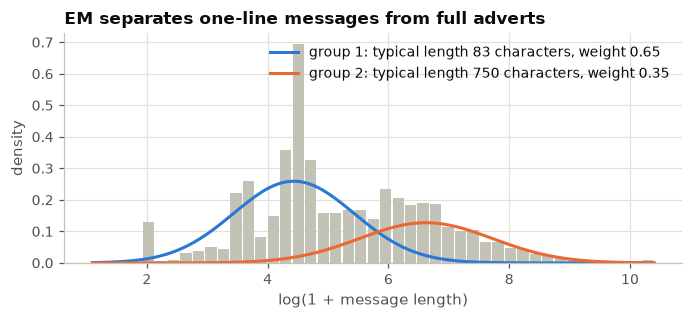

In [34]:
x_len = np.log1p(df.loc[df["has_message"] == 1, "msg_len"].to_numpy(dtype=float))


# ---- algorithms/em.py ----
import numpy as np


def em_two_gaussians(x, mu, sigma, weight, max_iter=2000, tol=1e-6):
    log_lik = []
    for _ in range(max_iter):
        dens = weight * np.exp(-0.5 * ((x[:, None] - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
        log_lik.append(float(np.log(dens.sum(axis=1)).sum()))
        resp = dens / dens.sum(axis=1, keepdims=True)                 # E-step: P(group | x)
        nk = resp.sum(axis=0)                                         # M-step: weighted re-estimates
        mu = (resp * x[:, None]).sum(axis=0) / nk
        sigma = np.sqrt((resp * (x[:, None] - mu) ** 2).sum(axis=0) / nk)
        weight = nk / len(x)
        if len(log_lik) > 1 and abs(log_lik[-1] - log_lik[-2]) < tol:
            break
    return mu, sigma, weight, log_lik


mu0 = np.percentile(x_len, [25, 75])
sigma0 = np.array([x_len.std(), x_len.std()])
mu_em, sigma_em, w_em, ll_hist = em_two_gaussians(x_len, mu0, sigma0, np.array([0.5, 0.5]))
gm1 = GaussianMixture(2, means_init=mu0.reshape(-1, 1), weights_init=[0.5, 0.5],
                      precisions_init=(1 / sigma0 ** 2).reshape(-1, 1, 1), tol=1e-10, max_iter=1000,
                      reg_covar=1e-12).fit(x_len.reshape(-1, 1))
print(f"start: means {mu0.round(2)}  ->  after {len(ll_hist)} iterations: means {mu_em.round(3)}, "
      f"std {sigma_em.round(3)}, weights {w_em.round(3)}")
print("log-likelihood, first five iterations:", [round(v, 1) for v in ll_hist[:5]], "(it never decreases)")
print("scikit-learn means:", gm1.means_.ravel().round(3))
assert np.all(np.diff(ll_hist) > -1e-6)
assert np.allclose(np.sort(mu_em), np.sort(gm1.means_.ravel()), atol=0.05)

grid_x = np.linspace(x_len.min(), x_len.max(), 300)
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.hist(x_len, bins=45, density=True, color=GRAY, rwidth=0.9)
for j, lab in enumerate(["group 1", "group 2"]):
    pdf = w_em[j] * np.exp(-0.5 * ((grid_x - mu_em[j]) / sigma_em[j]) ** 2) / (sigma_em[j] * np.sqrt(2 * np.pi))
    ax.plot(grid_x, pdf, color=C[j], label=f"{lab}: typical length {np.expm1(mu_em[j]):,.0f} characters, weight {w_em[j]:.2f}")
ax.set_xlabel("log(1 + message length)")
ax.set_ylabel("density")
ax.legend(loc="upper right")
ax.set_title("EM separates one-line messages from full adverts")
savefig("fig_em_length")

In [35]:
L10 = L[:, :10]
bic = []
for k in [4, 8, 12, 16, 20, 24]:
    g = GaussianMixture(k, covariance_type="diag", random_state=SEED, n_init=2).fit(L10)
    bic.append({"components": k, "BIC": g.bic(L10)})
bic = pd.DataFrame(bic)
display(bic.T)

gmm = GaussianMixture(K, covariance_type="diag", random_state=SEED, n_init=3).fit(L10)
resp = gmm.predict_proba(L10)
gmm_labels = resp.argmax(axis=1)
gmm_metrics = {
    "components": K,
    "ari_vs_kmeans": float(adjusted_rand_score(kmeans.labels_, gmm_labels)),
    "silhouette": float(silhouette_score(L, gmm_labels, metric="cosine")),
    "share_soft_below_0.9": float((resp.max(axis=1) < 0.9).mean()),
}
print(gmm_metrics)
between = np.argsort(resp.max(axis=1))[:3]
for i in between:
    top2 = resp[i].argsort()[::-1][:2]
    print(f"  shared between group {top2[0]} ({resp[i, top2[0]]:.2f}) and group {top2[1]} ({resp[i, top2[1]]:.2f}): "
          + ct["message"].iloc[i][:90].replace("\n", " "))

,0,1,2,3,4,5
components,4.000,8.000,12.000,16.000,20.000,24.000
BIC,-62065.667,-76100.165,-83597.419,-88356.404,-91557.712,-93553.292


{'components': 16, 'ari_vs_kmeans': 0.26972838736506066, 'silhouette': 0.06941115707798534, 'share_soft_below_0.9': 0.13778075762655045}
  shared between group 4 (0.38) and group 7 (0.29): movie milf    https://community.screwfix.com/proxy.php?link=https://tubesweet.com/ https:/
  shared between group 2 (0.38) and group 5 (0.29): Your Domain Name https://galxe-web3.com/2023/11/19/galxes-market-cap-reaches-126-77m-with-
  shared between group 4 (0.42) and group 10 (0.31): <u>Unlish your wild nature with hot girls</u> - <a href=https://bit.ly/3CSuwI7><b>click he


## 7.4 Campaigns over time (the campaign dimension of the cube)

year,2020,2021,2022,2023,2024,2025
"C10: wek, gotodate, promo",1,0,572,180,3,93
"C5: google, hello, cc",1,20,17,104,56,33
"C1: hi, website, backlinks",11,19,28,185,138,58
"C3: на, для, по",33,4,6,74,23,6
"C4: business, best, new",5,13,16,76,38,44
short / no shared vocabulary,1,6,3,170,140,25
"C7: click, unsubscribe, just",1,9,9,27,55,14
"C6: online, casino, games",0,2,16,31,31,12
"C13: seo, digital, ranks",5,26,13,48,33,17
"C0: cialis, viagra, prescription",0,0,5,49,24,37


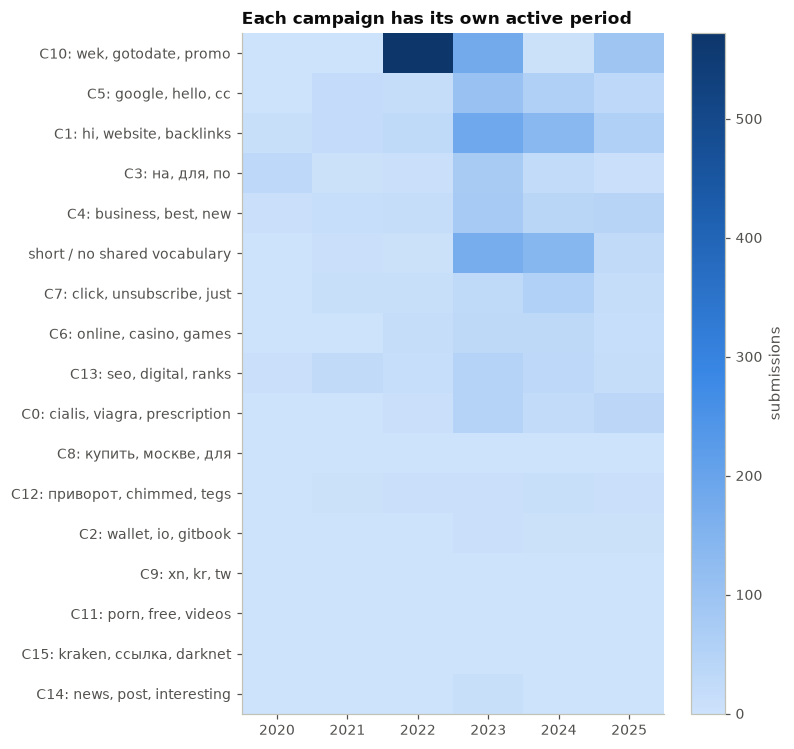

In [36]:
camp_year = (df[df["timestamp"].notna() & df["campaign"].notna()]
             .assign(year=lambda d: d["year"].astype(int), campaign=lambda d: d["campaign"].astype(int))
             .pivot_table(index="campaign", columns="year", values="id", aggfunc="count", fill_value=0))
camp_year = camp_year.reindex(campaigns["campaign"]).dropna(how="all").fillna(0).astype(int)
camp_year.index = [names_c[list(campaigns["campaign"]).index(c)] for c in camp_year.index]
display(camp_year)

fig, ax = plt.subplots(figsize=(7.2, 0.33 * len(camp_year) + 1.3))
im = ax.imshow(camp_year.to_numpy(), cmap=SEQ, aspect="auto")
ax.set_xticks(range(camp_year.shape[1]), camp_year.columns)
ax.set_yticks(range(len(camp_year)), camp_year.index)
ax.grid(False)
fig.colorbar(im, ax=ax, label="submissions")
ax.set_title("Each campaign has its own active period")
savefig("fig_campaign_year")

METRICS["clustering"] = {
    "templates_clustered": int(len(ct)), "templates_no_vocabulary": int(len(no_vocab)), "k": K,
    "k_scan": k_scan.to_dict("records"), "kmeans_silhouette": km_sil,
    "kmedoids": kmedoids_metrics, "gmm": gmm_metrics, "gmm_bic": bic.to_dict("records"),
    "em_1d": {"means_log": mu_em.tolist(), "typical_length": np.expm1(mu_em).tolist(), "weights": w_em.tolist(),
              "iterations": len(ll_hist)},
    "campaigns": campaigns.to_dict("records"),
}

**Analysis.**

- **No natural k.** SSE falls smoothly with no sharp elbow, and the silhouette is still rising slowly at the
  largest k tried. Spam campaigns share vocabulary (links, greetings, sales words), so the groups overlap. The
  k with the best silhouette inside the range an operator can review was used. A silhouette around 0.25
  means the clusters are coarse topics, not crisp groups, and they should be read that way.
- **The campaigns are readable.** The top terms name them: the "financial robot" money adverts, SEO and
  backlink offers, pharmacy, casino, crypto wallets, Russian-language adverts, and so on.
- **Honeypot behaviour is a property of the campaign.** Hit rates range from almost 0% to almost 100% between
  campaigns. The swings found by OLAP follow from this: 2022 was dominated by the financial-robot campaign,
  whose bot fills every field, and late 2023 by the short-message group, which mostly does not.
- **What text clustering cannot do.** The templates with no shared vocabulary are mostly one-line messages,
  including the one-sentence price enquiry translated into dozens of languages. No two versions share a word,
  so no text clustering can group them. Apriori (Section 5) did catch that campaign through its shape: short,
  no link, joined name. The two unsupervised methods complement each other.
- **K-medoids** gives each cluster a real message as its centre, which is what an operator wants to read. On
  the same sample its silhouette is a little lower than that of K-means and the two partitions agree only
  partly (adjusted Rand index well below 1), as expected when the cluster structure is weak.
- **EM** in one dimension splits the messages into one-liners and full adverts. On the text representation it
  gives soft memberships: a visible share of templates is not clearly in one group, and the examples are
  messages that mix two themes. BIC keeps falling as components are added, which again says there is no sharp
  number of groups. Its hard labels agree with K-means less than K-medoids does.
- **Choice for the software.** K-means, because assigning a new submission needs only the distance to k
  centroids, and because its partition scored best here. The medoid messages are shown beside each campaign as
  its readable example.

# 8. Task A: predicting honeypot evasion (supervised classification)

**Type of learning.** Supervised. The label `honeypot_filled` was recorded by the form itself, so it is an
observed fact about each submission, not something a rule produced.

**Why it is needed here.** Section 4 showed that the honeypot misses a growing share of spam. If the features
of a submission predict which senders evade the honeypot, the operator knows which kind of spam needs a second
line of defence, and the comparison shows which family of model reads these features best.

**Protocol (the same for every model).**

- Rows: the timestamped submissions with a usable label (the window without a honeypot, Section 1.3, is excluded).
  Features: the 45 columns built in Section 2. No time feature and nothing derived from the honeypot field.
- **Grouped 5-fold cross-validation.** All copies of a message template stay in the same fold; otherwise a
  model could score well by recognising a message it has already seen.
- **Time split.** Train on 2020-2023, test on 2024-2025. This is the honest test for a deployed system: the
  model always predicts the future from the past.
- Scalers and PCA are fitted on the training part only. Hyper-parameters are tuned on the 2020-2023 period
  only, so the 2024-2025 test rows are never used for any decision.
- Metrics come from the confusion matrix: accuracy, precision, recall, specificity, F1, balanced accuracy
  (the mean of recall and specificity) and ROC AUC. Training time, prediction time and model size are also
  recorded, because the software must run on a small server.

In [37]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import confusion_matrix, mutual_info_score, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.naive_bayes import BernoulliNB, GaussianNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier, export_text

rows_a = np.where(df["honeypot_filled"].notna())[0]
XA = X_all.iloc[rows_a].to_numpy(dtype=float)
yA = df["honeypot_filled"].iloc[rows_a].astype(int).to_numpy()
tid = df["template_id"].iloc[rows_a]
groups_a = np.where(tid != "", tid, "row" + df["id"].iloc[rows_a].astype(str)).astype(str)
year_a = df["year"].iloc[rows_a].astype(int).to_numpy()
past, future = year_a <= 2023, year_a >= 2024
print(f"Task A: {len(yA):,} rows, {XA.shape[1]} features, {len(set(groups_a)):,} template groups")
print(f"class balance: {yA.mean():.1%} filled | train period 2020-2023: {past.sum():,} rows ({yA[past].mean():.1%} filled) "
      f"| test period 2024-2025: {future.sum():,} rows ({yA[future].mean():.1%} filled)")

Task A: 2,209 rows, 45 features, 824 template groups
class balance: 71.2% filled | train period 2020-2023: 1,837 rows (69.2% filled) | test period 2024-2025: 372 rows (80.9% filled)


## 8.1 Evaluation from the confusion matrix

|  | predicted filled | predicted empty |
| --- | --- | --- |
| **actually filled** | TP | FN |
| **actually empty** | FP | TN |

accuracy = (TP + TN) / all, precision = TP / (TP + FP), recall = TP / (TP + FN),
specificity = TN / (TN + FP), F1 = 2 x precision x recall / (precision + recall).

In [38]:
# ---- algorithms/evaluation.py ----
def confusion_counts(y_true, y_pred):
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    return tp, fn, fp, tn


def metrics_from_counts(tp, fn, fp, tn):
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    specificity = tn / (tn + fp) if tn + fp else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"accuracy": (tp + tn) / (tp + fn + fp + tn), "precision": precision, "recall": recall,
            "specificity": specificity, "f1": f1, "balanced_acc": (recall + specificity) / 2}


def scores_of(model, X):
    """A continuous score for ROC analysis: class-1 probability, or the signed distance to the boundary."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


def evaluate_split(model, X, y, train, test):
    m = clone(model)
    t0 = time.perf_counter()
    m.fit(X[train], y[train])
    fit_s = time.perf_counter() - t0
    t0 = time.perf_counter()
    pred = m.predict(X[test])
    predict_ms = (time.perf_counter() - t0) / len(test) * 1000
    score = scores_of(m, X[test])
    out = metrics_from_counts(*confusion_counts(y[test], pred))
    out.update(auc=roc_auc_score(y[test], score), fit_s=fit_s, predict_ms=predict_ms, size_kb=len(pickle.dumps(m)) / 1024)
    return out, pred, score


def evaluate_cv(model, X, y, groups=None, n_splits=5):
    """Mean metrics over the folds, plus the pooled out-of-fold predictions and scores."""
    if groups is None:
        splits = StratifiedKFold(n_splits, shuffle=True, random_state=SEED).split(X, y)
    else:
        splits = StratifiedGroupKFold(n_splits, shuffle=True, random_state=SEED).split(X, y, groups)
    folds, pred_all, score_all = [], np.zeros(len(y), dtype=int), np.zeros(len(y))
    for train, test in splits:
        out, pred_all[test], score_all[test] = evaluate_split(model, X, y, train, test)
        folds.append(out)
    folds = pd.DataFrame(folds)
    summary = folds.mean().to_dict()
    summary["balanced_acc_std"] = float(folds["balanced_acc"].std())
    summary["f1_std"] = float(folds["f1"].std())
    return summary, pred_all, score_all


# The hand-written formulas agree with scikit-learn's confusion matrix.
_check = LogisticRegression(max_iter=2000).fit(StandardScaler().fit_transform(XA[past]), yA[past])
_pred = _check.predict(StandardScaler().fit(XA[past]).transform(XA[future]))
tn_, fp_, fn_, tp_ = confusion_matrix(yA[future], _pred).ravel()
assert confusion_counts(yA[future], _pred) == (tp_, fn_, fp_, tn_)
print("confusion_counts matches sklearn.metrics.confusion_matrix")

confusion_counts matches sklearn.metrics.confusion_matrix


## 8.2 Decision tree: entropy, information gain (ID3) and gain ratio (C4.5)

**What it is.** A tree of questions about the attributes. At each node the algorithm picks the attribute that
makes the classes purest.

- **Entropy** of a node: `H = -sum p_c log2 p_c`. It is 0 for a pure node and 1 for a 50/50 node.
- **ID3** picks the attribute with the highest **information gain**: entropy before the split minus the
  weighted entropy after it.
- Information gain favours attributes with many distinct values (an ID-like attribute splits the data into
  tiny pure groups). **C4.5** corrects this with the **gain ratio**: information gain divided by the *split
  information*, the entropy of the split itself.

**Why it is needed here.** A tree produces if-then rules that can be set beside FormTrap's 14 hand-written
rules.

**Implementation.** Entropy, information gain and gain ratio are computed from scratch for the root node on
the discretized attributes. Two attributes with many values are included on purpose to show the bias.

In [39]:
# ---- algorithms/decision_tree.py ----
import numpy as np


def entropy_of(labels):
    _, counts = np.unique(labels, return_counts=True)
    p = counts / counts.sum()
    return float(-(p * np.log2(p)).sum())


def split_measures(attribute, labels):
    values, counts = np.unique(attribute, return_counts=True)
    weights = counts / counts.sum()
    after = sum(w * entropy_of(labels[attribute == v]) for v, w in zip(values, weights))
    gain = entropy_of(labels) - after
    split_info = float(-(weights * np.log2(weights)).sum())
    return {"distinct values": len(values), "information gain": gain, "split information": split_info,
            "gain ratio": gain / split_info if split_info else 0.0}


d_a = df.iloc[rows_a]
candidates = pd.DataFrame({
    "length bin": d_a["len_bin"].astype(str),
    "url bin": d_a["url_bin"].astype(str),
    "script": d_a["script"],
    "name is joined": d_a["name_joined"],
    "e-mail type": np.select([d_a["has_email"].eq(0), d_a["email_free"].eq(1), d_a["email_ru"].eq(1)],
                             ["none", "free mail", "russian"], default="other"),
    "phone format": np.select([d_a["has_phone"].eq(0), d_a["phone_ru_format"].eq(1)], ["none", "russian"], default="other"),
    "money keyword": d_a["kw_money"],
    "e-mail domain (many values)": d_a["email_domain"],
    "template id (almost unique)": groups_a,
}).reset_index(drop=True)

print(f"entropy of the root node: {entropy_of(yA):.4f} bits ({yA.mean():.1%} filled)")
root = pd.DataFrame({c: split_measures(candidates[c].to_numpy(), yA) for c in candidates}).T
root["distinct values"] = root["distinct values"].astype(int)
display(root.sort_values("information gain", ascending=False))
# information gain is the mutual information between attribute and label (scikit-learn reports it in nats)
assert np.isclose(root.loc["url bin", "information gain"], mutual_info_score(candidates["url bin"], yA) / math.log(2))
id3_choice, c45_choice = root["information gain"].idxmax(), root["gain ratio"].idxmax()
print(f"ID3 would split on: {id3_choice}   |   C4.5 would split on: {c45_choice}")
METRICS["tree_root"] = {"root_entropy": entropy_of(yA), "id3_choice": id3_choice, "c45_choice": c45_choice,
                        "table": root.reset_index().rename(columns={"index": "attribute"}).to_dict("records")}

entropy of the root node: 0.8660 bits (71.2% filled)


,distinct values,information gain,split information,gain ratio
template id (almost unique),824,0.642,8.935,0.072
length bin,5,0.265,1.629,0.163
url bin,3,0.212,1.334,0.159
name is joined,2,0.201,0.808,0.249
e-mail domain (many values),40,0.149,3.209,0.046
money keyword,2,0.106,0.991,0.107
script,4,0.055,0.715,0.076
e-mail type,4,0.028,1.379,0.020
phone format,3,0.012,0.796,0.015


ID3 would split on: template id (almost unique)   |   C4.5 would split on: name is joined

The template id has the highest information gain of all: with thousands of values, each branch holds one or
two rows and is trivially pure. A tree built on it would memorise the training data and predict nothing for a
new template. Its split information is equally large, so its gain ratio drops and C4.5 picks a real attribute.
This is the "ID3 fails" case from the lectures, on real data.

The full tree below is built with scikit-learn. Its algorithm is CART (binary splits on numeric thresholds)
with the entropy criterion, so each split is chosen by information gain as in ID3, but it is not a literal ID3
or C4.5 tree. Depth is the main control against over-fitting, and it is tuned next.

## 8.3 Tuning on the training period: tree depth and K for KNN

**KNN, what it is.** To classify a new point, find the K training points nearest to it and take a majority
vote. There is no training step; the stored data is the model. **Why here:** "a submission behaves like the
submissions it resembles" is exactly the campaign idea of Section 7, used for prediction. It depends directly
on the distance measures of Section 3, which is why scaling matters so much for it.

chosen tree depth: 4 | chosen K: 7


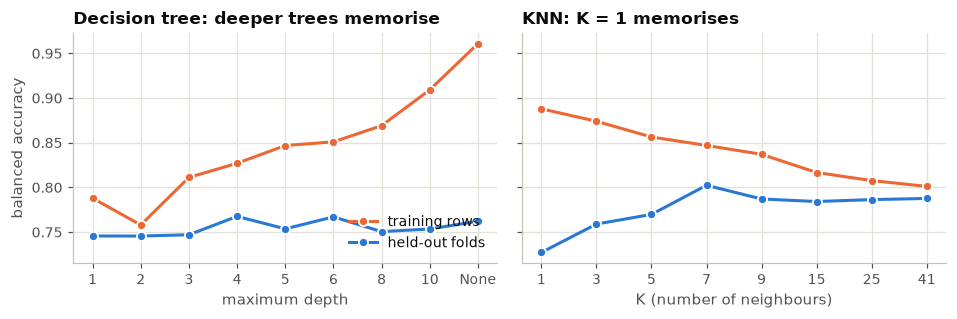

In [40]:
def tune(make_model, values, X, y, groups):
    rows = []
    for v in values:
        model = make_model(v)
        cv_summary, _, _ = evaluate_cv(model, X, y, groups)
        fitted = clone(model).fit(X, y)
        train_ba = metrics_from_counts(*confusion_counts(y, fitted.predict(X)))["balanced_acc"]
        rows.append({"value": str(v), "train": train_ba, "validation": cv_summary["balanced_acc"]})
    return pd.DataFrame(rows)


depth_scan = tune(lambda d: DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=SEED),
                  [1, 2, 3, 4, 5, 6, 8, 10, None], XA[past], yA[past], groups_a[past])
k_scan_knn = tune(lambda k: make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k)),
                  [1, 3, 5, 7, 9, 15, 25, 41], XA[past], yA[past], groups_a[past])
best_depth = depth_scan.loc[depth_scan["validation"].idxmax(), "value"]
DEPTH = None if best_depth == "None" else int(best_depth)
KNN_K = int(k_scan_knn.loc[k_scan_knn["validation"].idxmax(), "value"])
print(f"chosen tree depth: {DEPTH} | chosen K: {KNN_K}")

fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.0), sharey=True)
for ax, scan, title, xlabel in [(axes[0], depth_scan, "Decision tree: deeper trees memorise", "maximum depth"),
                                (axes[1], k_scan_knn, "KNN: K = 1 memorises", "K (number of neighbours)")]:
    xs = range(len(scan))
    ax.plot(xs, scan["train"], color=C[1], marker="o", label="training rows")
    ax.plot(xs, scan["validation"], color=C[0], marker="o", label="held-out folds")
    ax.set_xticks(xs, scan["value"])
    ax.set_xlabel(xlabel)
    ax.set_title(title)
axes[0].set_ylabel("balanced accuracy")
axes[0].legend(loc="lower right")
savefig("fig_tuning")

The gap between the two lines is over-fitting: training accuracy keeps rising with depth (and is perfect for
K = 1, where every point is its own nearest neighbour) while accuracy on held-out folds levels off or falls.
The values that are best on the held-out folds are used from here on.

## 8.4 KNN from scratch

In [41]:
# ---- algorithms/knn.py ----
import numpy as np


def knn_predict(X_train, y_train, X_test, k):
    preds, ties = [], []
    for x in X_test:
        dist = np.sqrt(((X_train - x) ** 2).sum(axis=1))          # Euclidean distance to every training row
        nearest = np.argsort(dist, kind="stable")[:k + 1]         # the K nearest (and the next one, to detect ties)
        preds.append(int(y_train[nearest[:k]].sum() * 2 > k))     # majority vote
        ties.append(bool(np.isclose(dist[nearest[k - 1]], dist[nearest[k]], atol=1e-6)))
    return np.array(preds), np.array(ties)


scaler = StandardScaler().fit(XA[past])
Ztr, Zte = scaler.transform(XA[past]), scaler.transform(XA[future][:300])
mine, tied = knn_predict(Ztr, yA[past], Zte, KNN_K)
theirs = KNeighborsClassifier(n_neighbors=KNN_K).fit(Ztr, yA[past]).predict(Zte)
print(f"from-scratch KNN agrees with scikit-learn on {np.mean(mine == theirs):.1%} of 300 test rows; "
      f"{tied.sum()} rows have a distance tie at the K-th neighbour (identical feature vectors), "
      f"where the choice of neighbour is arbitrary")
assert (mine == theirs)[~tied].all()

# Scaling matters for a distance-based method.
raw_cols = df[TEXT_F + CONTACT_F].iloc[rows_a].to_numpy(dtype=float)
unscaled, _, _ = evaluate_cv(KNeighborsClassifier(n_neighbors=KNN_K), raw_cols, yA, groups_a)
scaled, _, _ = evaluate_cv(make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=KNN_K)), XA, yA, groups_a)
knn_scaling = {"raw features": unscaled["balanced_acc"], "log + standardized": scaled["balanced_acc"]}
print("KNN balanced accuracy (5-fold):", {k: round(v, 3) for k, v in knn_scaling.items()})

from-scratch KNN agrees with scikit-learn on 98.7% of 300 test rows; 172 rows have a distance tie at the K-th neighbour (identical feature vectors), where the choice of neighbour is arbitrary


KNN balanced accuracy (5-fold): {'raw features': 0.748, 'log + standardized': 0.783}


## 8.5 Mahalanobis distance classifier

**What it is.** Assign a point to the class whose mean is nearest, measuring distance with
`d(x, mu) = sqrt((x - mu)^T S^-1 (x - mu))`, where S is the covariance matrix of that class. Dividing by the
covariance removes the effect of scale and of correlation between features; with S = identity it reduces to
Euclidean distance.

**Why it is needed here.** The features are strongly correlated (Section 2.2). Euclidean distance to a class
mean counts correlated features twice; Mahalanobis distance does not.

**Implementation.** From scratch, following the lecture steps: mean vector per class, covariance matrix per
class, inverse, distance of the new point to each class, decision. It runs on PCA components because the raw
covariance matrix is singular (Section 6).

In [42]:
# ---- algorithms/mahalanobis.py ----
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin


class MahalanobisClassifier(ClassifierMixin, BaseEstimator):
    """Nearest class mean under the Mahalanobis distance, with one covariance matrix per class."""

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.means_ = [X[y == c].mean(axis=0) for c in self.classes_]                                # step 1
        self.inv_covs_ = [np.linalg.pinv(np.cov(X[y == c], rowvar=False)) for c in self.classes_]    # steps 2-3
        return self

    def distances(self, X):
        return np.column_stack([np.sqrt(np.clip(np.einsum("ij,jk,ik->i", X - m, s, X - m), 0, None))
                                for m, s in zip(self.means_, self.inv_covs_)])                       # step 4

    def decision_function(self, X):
        d = self.distances(X)
        return d[:, 0] - d[:, 1]            # positive when the point is closer to class 1

    def predict(self, X):
        return self.classes_[self.distances(X).argmin(axis=1)]                                       # step 5


prep_pca = make_pipeline(StandardScaler(), PCA(0.90)).fit(XA[past])
Ptr, Pte = prep_pca.transform(XA[past]), prep_pca.transform(XA[future])
maha = MahalanobisClassifier().fit(Ptr, yA[past])
d_one = maha.distances(Pte[:1])[0]
print(f"{Ptr.shape[1]} PCA components. One test point: distance to class 'empty' = {d_one[0]:.2f}, "
      f"to class 'filled' = {d_one[1]:.2f}  ->  predicted {'filled' if d_one[1] < d_one[0] else 'empty'}, "
      f"actual {'filled' if yA[future][0] else 'empty'}")
maha_cv, _, _ = evaluate_cv(make_pipeline(StandardScaler(), PCA(0.90), MahalanobisClassifier()), XA, yA, groups_a)
eucl_cv, _, _ = evaluate_cv(make_pipeline(StandardScaler(), PCA(0.90), NearestCentroid()), XA, yA, groups_a)
maha_vs_eucl = {"Mahalanobis nearest mean": maha_cv["balanced_acc"], "Euclidean nearest mean": eucl_cv["balanced_acc"]}
print("balanced accuracy (5-fold):", {k: round(v, 3) for k, v in maha_vs_eucl.items()})

from scipy.spatial.distance import mahalanobis as scipy_mahalanobis
assert np.isclose(d_one[1], scipy_mahalanobis(Pte[0], maha.means_[1], maha.inv_covs_[1]))
print("the from-scratch distance equals scipy.spatial.distance.mahalanobis")

24 PCA components. One test point: distance to class 'empty' = 14.31, to class 'filled' = 18.65  ->  predicted empty, actual filled


balanced accuracy (5-fold): {'Mahalanobis nearest mean': 0.785, 'Euclidean nearest mean': 0.767}
the from-scratch distance equals scipy.spatial.distance.mahalanobis


### What PCA does to the other models

The Mahalanobis classifier cannot run without PCA here, because the covariance matrix of the raw features is
singular. KNN and logistic regression can, so the same models are scored on all 45 standardized features and
on the principal components that keep 90% of the variance.

In [43]:
pca_effect = {}
for name, clf in [("KNN", KNeighborsClassifier(n_neighbors=KNN_K)), ("Logistic regression", LogisticRegression(max_iter=2000))]:
    full, _, _ = evaluate_cv(make_pipeline(StandardScaler(), clone(clf)), XA, yA, groups_a)
    reduced, _, _ = evaluate_cv(make_pipeline(StandardScaler(), PCA(0.90), clone(clf)), XA, yA, groups_a)
    pca_effect[name] = {"all 45 features": full["balanced_acc"], "PCA, 90% of variance": reduced["balanced_acc"],
                        "AUC, all features": full["auc"], "AUC, PCA": reduced["auc"]}
display(pd.DataFrame(pca_effect).T)

,all 45 features,"PCA, 90% of variance","AUC, all features","AUC, PCA"
KNN,0.783,0.786,0.868,0.865
Logistic regression,0.791,0.766,0.880,0.868


**Analysis.** KNN scores the same with and without PCA: the directions PCA removed carried nothing its
distances used, which is what redundancy means. Logistic regression loses about two points, because it can
still draw on small-variance directions that PCA throws away. PCA is therefore applied only where it is
required: the Mahalanobis classifier, whose covariance matrix it makes invertible, and the Gaussian mixture.

## 8.6 Naive Bayes: which variant?

**What it is.** Bayes' theorem with the "naive" assumption that features are independent given the class:
`P(class | x) is proportional to P(class) x product of P(x_i | class)`. The class with the larger product
wins.

**Which variant.** The likelihood `P(x_i | class)` must match the type of feature: **Gaussian** for continuous
values, **Bernoulli** for yes/no flags, **Multinomial** for word counts (used in Task B). Task A mixes
continuous and binary features, so both candidates are tried.

In [44]:
bin_idx = [FEATURES.index(c) for c in BINARY_F]
nb_variants = {
    "Gaussian NB, all 45 features": make_pipeline(StandardScaler(), GaussianNB()),
    "Bernoulli NB, the 25 binary features": make_pipeline(ColumnTransformer([("binary", "passthrough", bin_idx)]), BernoulliNB(alpha=1.0)),
}
nb_cmp = {name: evaluate_cv(m, XA, yA, groups_a)[0] for name, m in nb_variants.items()}
display(pd.DataFrame(nb_cmp).T[["accuracy", "recall", "specificity", "balanced_acc", "auc"]])
best_nb = max(nb_cmp, key=lambda n: nb_cmp[n]["balanced_acc"])
print("variant used in the comparison:", best_nb)

,accuracy,recall,specificity,balanced_acc,auc
"Gaussian NB, all 45 features",0.496,0.320,0.931,0.625,0.834
"Bernoulli NB, the 25 binary features",0.822,0.879,0.679,0.779,0.857


variant used in the comparison: Bernoulli NB, the 25 binary features


## 8.7 Logistic regression

**What it is.** A linear model for classification. It computes a weighted sum `z = w . x + b` and passes it
through the sigmoid, `p = 1 / (1 + e^-z)`, which turns any number into a probability between 0 and 1. The class
is "filled" when `p` reaches a threshold, 0.5 by default. The weights are chosen to make the training labels as
probable as possible.

**Type of learning.** Supervised classification. Despite its name it predicts a class; the "regression" is a
linear model of the log-odds, `ln(p / (1 - p)) = z`.

**Why it is needed here.** It outputs a probability, so the operator can decide how strict the filter should
be. It has one weight per feature, which can be read and set beside FormTrap's hand-picked weights. And it is
the natural reference for the perceptron and the MLP that follow: the same linear form, trained on a smooth
loss instead of a count of mistakes.

**Implementation.** scikit-learn, on standardized features. The sigmoid for one row is worked by hand and
checked, as in the lectures, together with the reverse question (which `z` gives a chosen probability).

In [45]:
lr_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
lr_fit = clone(lr_model).fit(XA[past], yA[past])
x_row = lr_fit[0].transform(XA[future][:1])[0]                               # one standardized test row
z_row = float(x_row @ lr_fit[-1].coef_[0] + lr_fit[-1].intercept_[0])        # weighted sum
p_row = 1 / (1 + math.exp(-z_row))                                           # sigmoid
assert np.isclose(p_row, lr_fit.predict_proba(XA[future][:1])[0, 1])
print(f"one test row: z = w.x + b = {z_row:.3f}  ->  p = 1 / (1 + e^-z) = {p_row:.3f}  ->  "
      f"predicted {'filled' if p_row >= 0.5 else 'empty'} at threshold 0.5")
print(f"the reverse question: a probability of 0.90 needs z = ln(0.9 / 0.1) = {math.log(0.9 / 0.1):.3f}")

_, _, lr_oof = evaluate_cv(lr_model, XA, yA, groups_a)                       # out-of-fold probabilities
lr_thresholds = []
for threshold in (0.3, 0.4, 0.5, 0.6, 0.7):
    out = metrics_from_counts(*confusion_counts(yA, (lr_oof >= threshold).astype(int)))
    lr_thresholds.append({"threshold": threshold, "precision": out["precision"], "recall": out["recall"],
                          "specificity": out["specificity"], "balanced_acc": out["balanced_acc"]})
lr_thresholds = pd.DataFrame(lr_thresholds)
display(lr_thresholds)

one test row: z = w.x + b = -0.406  ->  p = 1 / (1 + e^-z) = 0.400  ->  predicted empty at threshold 0.5
the reverse question: a probability of 0.90 needs z = ln(0.9 / 0.1) = 2.197


,threshold,precision,recall,specificity,balanced_acc
0,0.300,0.851,0.945,0.590,0.767
1,0.400,0.858,0.929,0.621,0.775
2,0.500,0.872,0.913,0.670,0.791
3,0.600,0.882,0.879,0.709,0.794
4,0.700,0.897,0.829,0.764,0.797


**Analysis.** The table is the reason a probability is worth having. Moving the threshold trades recall
against specificity, and the operator can pick the row that matches the cost of each kind of error. A model
that outputs only a decision offers a single row. The weights themselves are shown in Section 8.11.

## 8.8 Perceptron and multi-layer network

**What it is.** A perceptron computes a weighted sum of the inputs plus a bias and outputs 1 if the sum is
positive. Training shows it one pattern at a time and, when it is wrong, moves the weights toward the correct
answer: `w <- w + eta (target - output) x`. It can only draw a straight boundary. A multi-layer perceptron
(MLP) puts a layer of such units in between and can draw curved boundaries.

**Why it is needed here.** To test whether a non-linear model reads these features better than the linear
ones, and at what cost in size and time.

wrong patterns per epoch: [287, 300, 302, 290, 298, 299, 301, 301, 304, 302, 299, 300, 299, 300, 301, 305, 296, 303, 297, 300]
balanced accuracy on 2024-2025: {'from scratch': 0.553, 'scikit-learn': 0.56}
the error count never reaches 0: the two classes are not linearly separable in these features


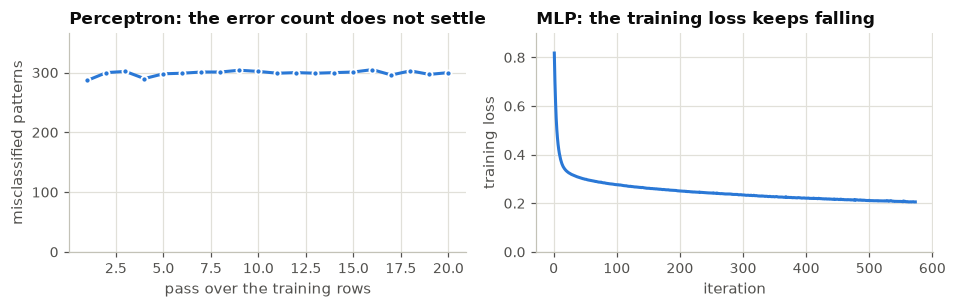

,training rows 2020-2023,later rows 2024-2025
MLP,0.887,0.513
Logistic regression,0.819,0.689


In [46]:
# ---- algorithms/perceptron.py ----
import numpy as np


def perceptron_train(X, y, epochs=20, eta=1.0):
    w, b = np.zeros(X.shape[1]), 0.0
    errors = []
    for _ in range(epochs):
        wrong = 0
        for x, target in zip(X, y):
            output = int(w @ x + b > 0)                # forward pass with a step activation
            delta = target - output                    # 0 if correct, +1 or -1 if wrong
            if delta:
                w += eta * delta * x                   # weight update
                b += eta * delta                       # bias update
                wrong += 1
        errors.append(wrong)
    return w, b, errors


w_p, b_p, err_hist = perceptron_train(Ztr, yA[past])
Zfu = scaler.transform(XA[future])
mine_p = (Zfu @ w_p + b_p > 0).astype(int)
sk_p = Perceptron(random_state=SEED).fit(Ztr, yA[past]).predict(Zfu)
perceptron_check = {"from scratch": metrics_from_counts(*confusion_counts(yA[future], mine_p))["balanced_acc"],
                    "scikit-learn": metrics_from_counts(*confusion_counts(yA[future], sk_p))["balanced_acc"]}
print("wrong patterns per epoch:", err_hist)
print("balanced accuracy on 2024-2025:", {k: round(v, 3) for k, v in perceptron_check.items()})
print("the error count never reaches 0: the two classes are not linearly separable in these features")

# Learning curves: the perceptron's mistakes per pass, and the MLP's training loss per iteration.
mlp_demo = make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(32,), max_iter=800, random_state=SEED)).fit(XA[past], yA[past])
mlp_loss = mlp_demo[-1].loss_curve_
fig, axes = plt.subplots(1, 2, figsize=(8.8, 2.9))
axes[0].plot(range(1, len(err_hist) + 1), err_hist, color=C[0], marker="o", markersize=4)
axes[0].set_ylim(0, max(err_hist) * 1.2)
axes[0].set_xlabel("pass over the training rows")
axes[0].set_ylabel("misclassified patterns")
axes[0].set_title("Perceptron: the error count does not settle")
axes[1].plot(range(1, len(mlp_loss) + 1), mlp_loss, color=C[0])
axes[1].set_ylim(0, max(mlp_loss) * 1.1)
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("training loss")
axes[1].set_title("MLP: the training loss keeps falling")
savefig("fig_learning_curves")

mlp_fit = {"training rows 2020-2023": metrics_from_counts(*confusion_counts(yA[past], mlp_demo.predict(XA[past])))["balanced_acc"],
           "later rows 2024-2025": metrics_from_counts(*confusion_counts(yA[future], mlp_demo.predict(XA[future])))["balanced_acc"]}
lr_gap = {"training rows 2020-2023": metrics_from_counts(*confusion_counts(yA[past], lr_fit.predict(XA[past])))["balanced_acc"],
          "later rows 2024-2025": metrics_from_counts(*confusion_counts(yA[future], lr_fit.predict(XA[future])))["balanced_acc"]}
display(pd.DataFrame({"MLP": mlp_fit, "Logistic regression": lr_gap}).T)

**Analysis.** The two curves show two different failures. The perceptron's error count stays near 300 per
pass and never falls: a single straight boundary cannot separate these classes, and each correction undoes an
earlier one. The MLP drives its training loss steadily down, and the table shows what that buys: it fits the
rows it was trained on far better than logistic regression does and is at chance on the later period, where
logistic regression keeps most of its score. The extra capacity was spent on the particular campaigns of
2020-2023.

## 8.9 All models under one protocol

In [47]:
class UrlRule(ClassifierMixin, BaseEstimator):
    """Hand-written baseline: a message with at least one URL is predicted to fill the honeypot."""

    def __init__(self, column=0):
        self.column = column

    def fit(self, X, y):
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        p = (X[:, self.column] > 0).astype(float)
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (X[:, self.column] > 0).astype(int)


MODELS_A = {
    "Baseline: majority class": DummyClassifier(strategy="most_frequent"),
    "Baseline: rule 'has a URL'": UrlRule(FEATURES.index("url_count")),
    "Naive Bayes": nb_variants[best_nb],
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "Decision tree": DecisionTreeClassifier(criterion="entropy", max_depth=DEPTH, random_state=SEED),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=KNN_K)),
    "Mahalanobis (PCA)": make_pipeline(StandardScaler(), PCA(0.90), MahalanobisClassifier()),
    "Perceptron": make_pipeline(StandardScaler(), Perceptron(random_state=SEED)),
    "MLP (one hidden layer)": make_pipeline(StandardScaler(), MLPClassifier(hidden_layer_sizes=(32,), max_iter=800, random_state=SEED)),
}
COLS = ["accuracy", "precision", "recall", "specificity", "f1", "balanced_acc", "auc"]
cv_a, ts_a, oof_a, oof_pred_a, ts_scores_a, ts_pred_a = {}, {}, {}, {}, {}, {}
train_idx, test_idx = np.where(past)[0], np.where(future)[0]
for name, model in MODELS_A.items():
    cv_a[name], oof_pred_a[name], oof_a[name] = evaluate_cv(model, XA, yA, groups_a)
    ts_a[name], ts_pred_a[name], ts_scores_a[name] = evaluate_split(model, XA, yA, train_idx, test_idx)
cv_a, ts_a = pd.DataFrame(cv_a).T, pd.DataFrame(ts_a).T
print("Grouped 5-fold cross-validation (mean over folds)")
display(cv_a[COLS + ["balanced_acc_std"]])
print("Time split: trained on 2020-2023, tested on 2024-2025")
display(ts_a[COLS])
print("Cost (time split)")
display(ts_a[["fit_s", "predict_ms", "size_kb"]].rename(columns={"fit_s": "training time (s)", "predict_ms": "prediction (ms per row)", "size_kb": "model size (KB)"}))

Grouped 5-fold cross-validation (mean over folds)


,accuracy,precision,recall,specificity,f1,balanced_acc,auc,balanced_acc_std
Baseline: majority class,0.712,0.712,1.000,0.000,0.832,0.500,0.500,0.000
Baseline: rule 'has a URL',0.820,0.851,0.906,0.607,0.877,0.756,0.756,0.030
Naive Bayes,0.822,0.874,0.879,0.679,0.875,0.779,0.857,0.046
Logistic regression,0.843,0.874,0.913,0.670,0.892,0.791,0.880,0.041
Decision tree,0.831,0.830,0.962,0.506,0.891,0.734,0.826,0.062
KNN,0.834,0.869,0.904,0.662,0.886,0.783,0.868,0.033
Mahalanobis (PCA),0.820,0.880,0.867,0.703,0.872,0.785,0.866,0.044
Perceptron,0.828,0.879,0.881,0.696,0.879,0.789,0.796,0.033
MLP (one hidden layer),0.824,0.866,0.892,0.657,0.878,0.775,0.841,0.039


Time split: trained on 2020-2023, tested on 2024-2025


,accuracy,precision,recall,specificity,f1,balanced_acc,auc
Baseline: majority class,0.809,0.809,1.000,0.000,0.895,0.500,0.500
Baseline: rule 'has a URL',0.812,0.847,0.937,0.282,0.890,0.609,0.609
Naive Bayes,0.543,0.805,0.575,0.408,0.671,0.492,0.472
Logistic regression,0.758,0.889,0.801,0.577,0.843,0.689,0.765
Decision tree,0.594,0.829,0.628,0.451,0.715,0.539,0.628
KNN,0.618,0.844,0.648,0.493,0.733,0.570,0.557
Mahalanobis (PCA),0.548,0.812,0.575,0.437,0.673,0.506,0.529
Perceptron,0.583,0.841,0.598,0.521,0.699,0.560,0.570
MLP (one hidden layer),0.656,0.815,0.744,0.282,0.778,0.513,0.587


Cost (time split)


,training time (s),prediction (ms per row),model size (KB)
Baseline: majority class,0.001,0.000,0.466
Baseline: rule 'has a URL',0.001,0.000,0.212
Naive Bayes,0.005,0.008,2.375
Logistic regression,0.058,0.003,2.487
Decision tree,0.012,0.001,3.354
KNN,0.004,0.020,662.287
Mahalanobis (PCA),0.008,0.007,21.192
Perceptron,0.013,0.004,2.700
MLP (one hidden layer),6.731,0.002,66.224


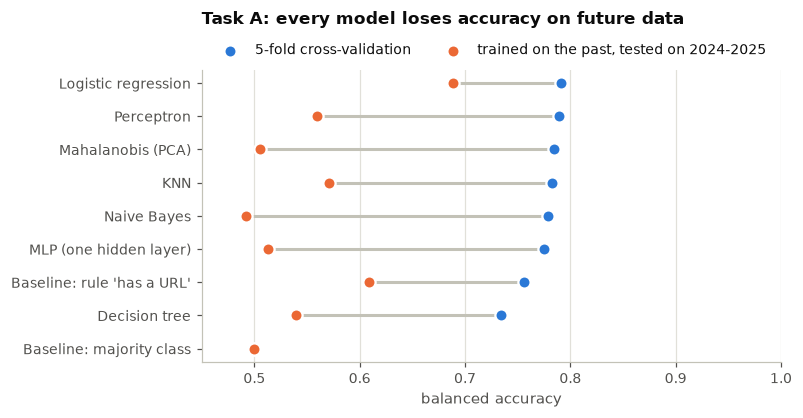

In [48]:
order = cv_a["balanced_acc"].sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(7.4, 3.9))
ypos = np.arange(len(order))
for y, name in zip(ypos, order):
    ax.plot([cv_a.loc[name, "balanced_acc"], ts_a.loc[name, "balanced_acc"]], [y, y], color=AXIS, linewidth=2, zorder=1)
ax.scatter(cv_a.loc[order, "balanced_acc"], ypos, s=64, color=C[0], edgecolors="white", linewidths=1.5, label="5-fold cross-validation", zorder=2)
ax.scatter(ts_a.loc[order, "balanced_acc"], ypos, s=64, color=C[1], edgecolors="white", linewidths=1.5, label="trained on the past, tested on 2024-2025", zorder=2)
ax.set_yticks(ypos, order)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel("balanced accuracy")
ax.set_xlim(0.45, 1.0)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=2)
ax.set_title("Task A: every model loses accuracy on future data", pad=30)
savefig("fig_task_a_models")

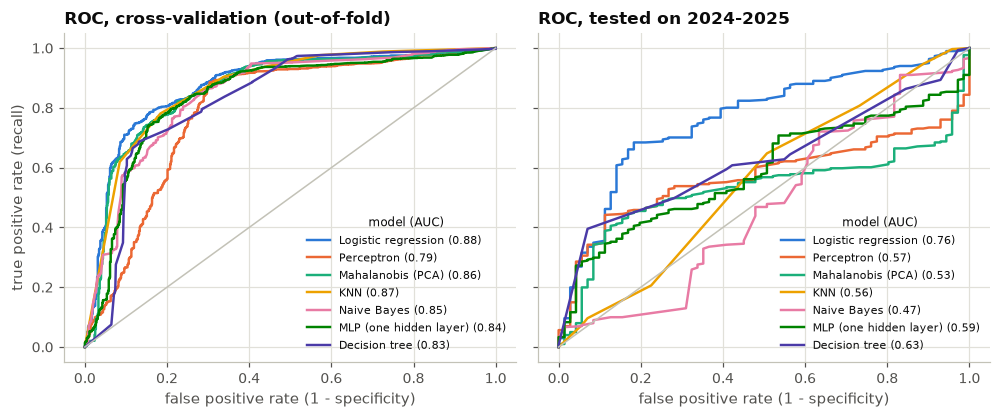

In [49]:
learned = [m for m in order if not m.startswith("Baseline")]
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.9), sharey=True)
for ax, src, y_true, title in [(axes[0], oof_a, yA, "ROC, cross-validation (out-of-fold)"),
                               (axes[1], ts_scores_a, yA[future], "ROC, tested on 2024-2025")]:
    for colour, name in zip(C, learned):
        fpr, tpr, _ = roc_curve(y_true, src[name])
        ax.plot(fpr, tpr, color=colour, linewidth=1.6, label=f"{name} ({roc_auc_score(y_true, src[name]):.2f})")
    ax.plot([0, 1], [0, 1], color=AXIS, linewidth=1)
    ax.set_xlabel("false positive rate (1 - specificity)")
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=7.5, title="model (AUC)", title_fontsize=8)
axes[0].set_ylabel("true positive rate (recall)")
savefig("fig_task_a_roc")

## 8.10 What trusting the recorded label would have done

Section 1.3 removed the twelve-month window in which the form had no honeypot. The same fitted models
are scored here on the 2024-2025 rows *as recorded*, with every window row counted as "left empty".

In [50]:
rec_rows = np.where(df["honeypot_recorded"].notna() & (df["year"] >= 2024))[0]
X_rec = X_all.iloc[rec_rows].to_numpy(dtype=float)
y_rec = df["honeypot_recorded"].iloc[rec_rows].astype(int).to_numpy()
recorded = {}
for name in learned:
    m = clone(MODELS_A[name]).fit(XA[past], yA[past])
    out = metrics_from_counts(*confusion_counts(y_rec, m.predict(X_rec)))
    recorded[name] = {"balanced acc, usable labels": ts_a.loc[name, "balanced_acc"], "balanced acc, as recorded": out["balanced_acc"],
                      "specificity, usable labels": ts_a.loc[name, "specificity"], "specificity, as recorded": out["specificity"]}
recorded = pd.DataFrame(recorded).T.astype(float)
print(f"test rows with usable labels: {future.sum():,} | test rows as recorded: {len(y_rec):,} "
      f"({(y_rec == 0).sum():,} 'empty', of which {int(in_window.sum()):,} are window rows)")
display(recorded)

test rows with usable labels: 372 | test rows as recorded: 1,019 (718 'empty', of which 647 are window rows)


,"balanced acc, usable labels","balanced acc, as recorded","specificity, usable labels","specificity, as recorded"
Logistic regression,0.689,0.744,0.577,0.688
Perceptron,0.560,0.550,0.521,0.503
Mahalanobis (PCA),0.506,0.624,0.437,0.673
KNN,0.570,0.673,0.493,0.698
Naive Bayes,0.492,0.632,0.408,0.689
MLP (one hidden layer),0.513,0.655,0.282,0.565
Decision tree,0.539,0.618,0.451,0.609


Trusting the recorded label changes the picture in three ways. The test set becomes almost three times
larger. Its class balance flips, from about 80% "filled" to about 30%. And most models score 5 to 14 points
*higher*, because the window adds hundreds of rows labelled "empty" that the models happen to call "empty".
The conclusions about which model works, and about how often the honeypot is evaded, would rest on rows whose
label says nothing about the sender. The figures with usable labels are the ones reported from here on.

## 8.11 What the models learned

best model on the time split: Logistic regression


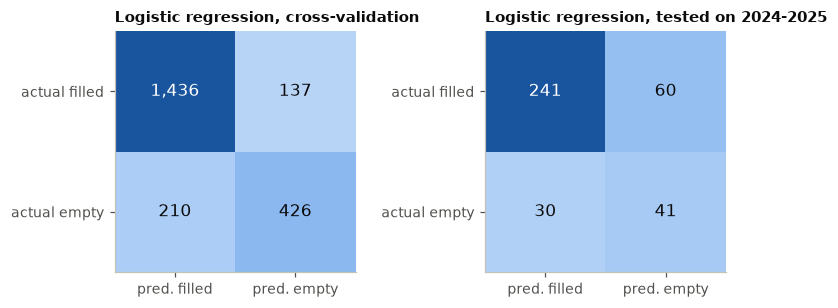

In [51]:
best_a = ts_a.loc[learned, "balanced_acc"].idxmax()
print(f"best model on the time split: {best_a}")
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.9))
for ax, (y_true, y_pred, title) in zip(axes, [(yA, oof_pred_a[best_a], "cross-validation"),
                                                (yA[future], ts_pred_a[best_a], "tested on 2024-2025")]):
    tp, fn, fp, tn = confusion_counts(y_true, y_pred)
    cm = np.array([[tp, fn], [fp, tn]])
    ax.imshow(cm, cmap=SEQ, vmin=0, vmax=cm.max() * 1.25)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, f"{v:,}", ha="center", va="center", fontsize=11, color="white" if v > cm.max() * 0.55 else INK)
    ax.set_xticks([0, 1], ["pred. filled", "pred. empty"])
    ax.set_yticks([0, 1], ["actual filled", "actual empty"])
    ax.grid(False)
    ax.set_title(f"{best_a}, {title}", fontsize=9.5)
savefig("fig_task_a_confusion")

Decision tree limited to depth 3, trained on 2020-2023 (count features are on a log(1 + x) scale):

|--- name_joined <= 0.50
|   |--- name_len <= 2.25
|   |   |--- cyrillic_ratio <= 0.19
|   |   |   |--- class: 1
|   |   |--- cyrillic_ratio >  0.19
|   |   |   |--- class: 0
|   |--- name_len >  2.25
|   |   |--- phone_ru_format <= 0.50
|   |   |   |--- class: 0
|   |   |--- phone_ru_format >  0.50
|   |   |   |--- class: 1
|--- name_joined >  0.50
|   |--- msg_len <= 3.88
|   |   |--- email_local_len <= 2.25
|   |   |   |--- class: 1
|   |   |--- email_local_len >  2.25
|   |   |   |--- class: 0
|   |--- msg_len >  3.88
|   |   |--- email_local_digits <= 0.35
|   |   |   |--- class: 1
|   |   |--- email_local_digits >  0.35
|   |   |   |--- class: 0



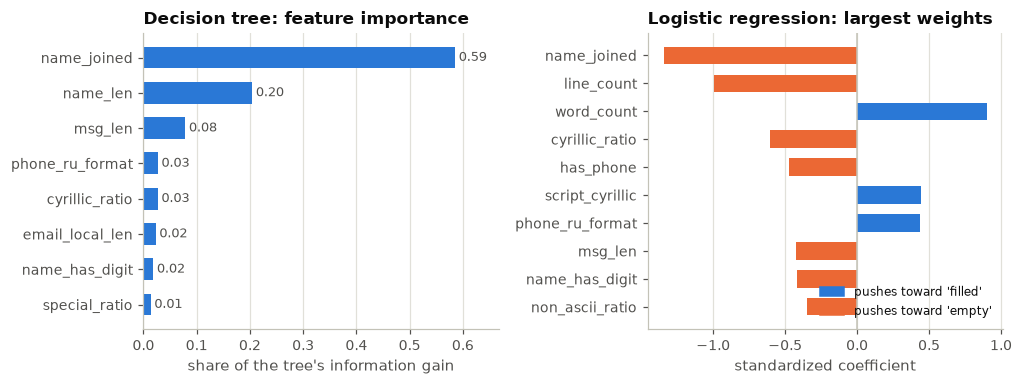

In [52]:
tree3 = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=SEED).fit(XA[past], yA[past])
print("Decision tree limited to depth 3, trained on 2020-2023 (count features are on a log(1 + x) scale):\n")
print(export_text(tree3, feature_names=FEATURES, decimals=2))

full_tree = clone(MODELS_A["Decision tree"]).fit(XA[past], yA[past])
importance = pd.Series(full_tree.feature_importances_, index=FEATURES).sort_values(ascending=False).head(8)
lr = clone(MODELS_A["Logistic regression"]).fit(XA[past], yA[past])
coef = pd.Series(lr[-1].coef_[0], index=FEATURES)
top_coef = coef.reindex(coef.abs().sort_values(ascending=False).index).head(10)

fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.6))
barh(axes[0], importance.index, importance.values, xlabel="share of the tree's information gain")
axes[0].set_title("Decision tree: feature importance")
colours = [C[0] if v > 0 else C[1] for v in top_coef.values]
axes[1].barh(list(top_coef.index), top_coef.values, color=colours, height=0.62)
axes[1].axvline(0, color=AXIS, linewidth=1)
axes[1].invert_yaxis()
axes[1].grid(axis="y", visible=False)
axes[1].set_xlabel("standardized coefficient")
axes[1].set_title("Logistic regression: largest weights")
axes[1].legend(handles=[plt.Rectangle((0, 0), 1, 1, color=C[0]), plt.Rectangle((0, 0), 1, 1, color=C[1])],
               labels=["pushes toward 'filled'", "pushes toward 'empty'"], loc="lower right", fontsize=8)
savefig("fig_task_a_explain")

In [53]:
# Error analysis for the best model on the future period.
err = df.iloc[rows_a[test_idx]].assign(pred=ts_pred_a[best_a], actual=yA[future])
err["outcome"] = np.select([(err["pred"] == 1) & (err["actual"] == 1), (err["pred"] == 0) & (err["actual"] == 0),
                            (err["pred"] == 1) & (err["actual"] == 0)], ["TP", "TN", "FP"], default="FN")
print("\noutcomes on 2024-2025 by year:")
display(pd.crosstab(err["year"].astype(int), err["outcome"]))
for kind, text in [("FP", "predicted 'filled' but the honeypot was left empty"), ("FN", "predicted 'empty' but the honeypot was filled")]:
    part = err[err["outcome"] == kind]
    print(f"\n{kind} ({len(part)} rows): {text}. Typical cases:")
    for msg, n in part["message"].str[:90].str.replace("\n", " ").value_counts().head(3).items():
        print(f"   x{n}  {msg!r}")

METRICS["task_a"] = {
    "rows": int(len(yA)), "features": int(XA.shape[1]), "train_rows": int(past.sum()), "test_rows": int(future.sum()),
    "positive_rate": float(yA.mean()), "positive_rate_train": float(yA[past].mean()), "positive_rate_test": float(yA[future].mean()),
    "tree_depth": DEPTH, "knn_k": KNN_K, "naive_bayes_variant": best_nb,
    "nb_variants": {k: v["balanced_acc"] for k, v in nb_cmp.items()},
    "knn_scaling": knn_scaling, "mahalanobis_vs_euclidean": maha_vs_eucl, "perceptron_check": perceptron_check,
    "pca_effect": pca_effect, "lr_thresholds": lr_thresholds.to_dict("records"),
    "mlp_train_vs_later": mlp_fit, "lr_train_vs_later": lr_gap,
    "depth_scan": depth_scan.to_dict("records"), "knn_scan": k_scan_knn.to_dict("records"),
    "cv": cv_a.reset_index().rename(columns={"index": "model"}).to_dict("records"),
    "time_split": ts_a.reset_index().rename(columns={"index": "model"}).to_dict("records"),
    "best_model_time_split": best_a,
    "tree_importance": importance.to_dict(), "lr_top_coefficients": top_coef.to_dict(),
    "as_recorded": recorded.reset_index().rename(columns={"index": "model"}).to_dict("records"),
    "as_recorded_test_rows": int(len(y_rec)),
}


outcomes on 2024-2025 by year:


outcome,FN,FP,TN,TP
year,,,,
2024,24,21,39,10
2025,36,9,2,231



FP (30 rows): predicted 'filled' but the honeypot was left empty. Typical cases:
   x3  'Заполучи желаемое прилагая минимум усилий <EMAIL> 000*** <SITE>'
   x2  'If you are looking to rank your local business on Google Maps in a specific area, this ser'
   x2  'На нашем сайте разнообразие интернет-провайдеров в вашем городе! Мы предлагаем разнообразн'

FN (60 rows): predicted 'empty' but the honeypot was filled. Typical cases:
   x3  '<NAME>'
   x2  'Salam, qiymətinizi bilmək istədim.'
   x1  'Choosing a secure payment method is essential for safe online gambling. PayPal and Skrill '


**Analysis of Task A.**

- **The features carry signal, and nothing leaked.** In cross-validation the learned models reach a balanced
  accuracy of 0.73 to 0.79 against 0.50 for the majority baseline, and an AUC of up to 0.88. No score is near
  1.00, which is what a real, noisy label looks like.
- **A one-line rule is hard to beat at a single threshold.** "The message has a URL" reaches a balanced
  accuracy of about 0.76; the best learned model about 0.79. The learned models are better at *ranking*
  submissions (AUC 0.80 to 0.88 against 0.76), which matters when a threshold has to be chosen.
- **Forward in time, most models fall to chance.** Trained on 2020-2023 and tested on 2024-2025, logistic
  regression keeps a balanced accuracy of about 0.69 (AUC about 0.77). Every other learned model lands between
  0.49 and 0.57, below the URL rule. The test period is small (372 rows, 71 of them "empty"), so differences of
  a few points mean nothing, but the gap between logistic regression and the rest, and between
  cross-validation and the time split, is far larger than that.
- **Why the future is different.** In 2025 almost every submission fills the honeypot, including the one-line
  price enquiry that almost never did in 2023 (the false negatives listed above). The form itself changed at
  that point (Section 1.3). Honeypot behaviour depends on how the form presents the hidden field and on the
  bot software, not only on what the message says, and content features cannot see either.
- **Naive Bayes.** The Bernoulli variant on the binary flags beats the Gaussian variant on all features by a
  wide margin: the count features are far from Gaussian even after the log transform.
- **KNN.** Scaling the features raises its balanced accuracy by about three points. Its model is the entire
  training set (hundreds of KB against 2-3 KB for the linear models) and it is the slowest to predict.
- **Mahalanobis.** It beats the Euclidean nearest-mean classifier on the same PCA components by about two
  points, the benefit of correcting for covariance. It models the shape of each class closely, so when the
  classes move it is at chance.
- **Perceptron.** Its balanced accuracy in cross-validation is close to that of logistic regression, but its
  AUC is the lowest of the learned models: it outputs a decision, not a graded score. The classes are not
  linearly separable, so its update rule never settles.
- **Decision tree.** The lowest and least stable in cross-validation. Its value is the readable rule set: the
  first question of the depth-3 tree, whether the name is a joined token, is the attribute the from-scratch
  gain ratio chose and the one Apriori put in its rules.

**Conclusion for the project.** Whether a sender fills the honeypot is moderately predictable inside one
period and poorly predictable forward in time. It is a property of the bot and the form, and both change. The
honeypot cannot be the only defence, and no model of honeypot behaviour can stand in for it; the content
itself has to be classified, which is Task B.

# 9. Task B: spam versus legitimate messages (supervised classification)

**Type of learning.** Supervised. Label 1 = a message received by this form (all spam), label 0 = a
legitimate message from the public SMS Spam Collection.

**Why it is needed here.** This is the model the software uses to score an incoming submission when the
honeypot is silent.

**Known weakness, stated up front.** The two classes come from different sources. A model can score well by
learning "which source" (message length, SMS slang, Cyrillic script) instead of "spam". Section 9.4 measures
how much of the score that explains.

**Features.** Words only. Each message becomes a vector of word counts (for Naive Bayes) or TF-IDF weights
(for the other models), built inside the cross-validation pipeline so the vocabulary never sees test folds.
Spam rows are distinct templates, so no copy of a training message appears in a test fold.

In [54]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer

merged["text"] = merged["text"].fillna("").astype(str)
textB = merged["text"].to_numpy(dtype=object)
yB = merged["label"].to_numpy()
print(f"Task B: {len(yB):,} messages, {yB.mean():.1%} spam")
display(merged.groupby(["source", "label"])["text"].agg(rows="size", median_length=lambda s: s.str.len().median()))

Task B: 7,639 messages, 40.9% spam


,,rows,median_length
source,label,,
formtrap,1,3122,318.500
sms_ham_uci,0,4517,53.000


## 9.1 Multinomial Naive Bayes from scratch

For text, the likelihood of a class is the product of the probabilities of the words in the message:

`P(word | class) = (count of the word in that class + alpha) / (all words in that class + alpha x vocabulary size)`

With `alpha = 0` a word that never occurred in one class gets probability 0 and wipes out the whole product
(the zero-frequency problem). **Laplace smoothing** (`alpha = 1`) adds one imaginary occurrence of every word
to every class.

In [55]:
# ---- algorithms/naive_bayes.py ----
import numpy as np


def mnb_fit(counts, y, alpha=1.0):
    log_prior = np.log(np.array([np.mean(y == c) for c in (0, 1)]))
    word_counts = np.vstack([np.asarray(counts[y == c].sum(axis=0)).ravel() for c in (0, 1)])
    log_likelihood = np.log((word_counts + alpha) / (word_counts.sum(axis=1, keepdims=True) + alpha * counts.shape[1]))
    return log_prior, log_likelihood, word_counts


def mnb_predict(counts, log_prior, log_likelihood):
    return np.asarray(counts @ log_likelihood.T + log_prior).argmax(axis=1)   # sums of logs instead of products


tr_b, te_b = train_test_split(np.arange(len(yB)), test_size=0.2, stratify=yB, random_state=SEED)
cvec = CountVectorizer(lowercase=True, min_df=2, max_features=20000)
Ctr, Cte = cvec.fit_transform(textB[tr_b]), cvec.transform(textB[te_b])
vocab = np.array(cvec.get_feature_names_out())
log_prior, log_lik, word_counts = mnb_fit(Ctr, yB[tr_b])
mine_nb = mnb_predict(Cte, log_prior, log_lik)
sk_nb = MultinomialNB(alpha=1.0).fit(Ctr, yB[tr_b]).predict(Cte)
print(f"from-scratch Multinomial NB agrees with scikit-learn on {np.mean(mine_nb == sk_nb):.2%} of {len(te_b):,} test messages")
assert np.mean(mine_nb == sk_nb) > 0.999

totals = word_counts.sum(axis=1)
worked = []
for w in ["free", "website", "money", "love", "ok"]:
    j = int(np.where(vocab == w)[0][0])
    worked.append({"word": w, "count in legitimate": int(word_counts[0, j]), "count in spam": int(word_counts[1, j]),
                   "P(word | legitimate)": math.exp(log_lik[0, j]), "P(word | spam)": math.exp(log_lik[1, j]),
                   "spam / legitimate ratio": math.exp(log_lik[1, j] - log_lik[0, j])})
print(f"words in legitimate class: {int(totals[0]):,} | words in spam class: {int(totals[1]):,} | vocabulary: {len(vocab):,}")
worked = pd.DataFrame(worked)
for col in ["P(word | legitimate)", "P(word | spam)"]:
    worked[col] = worked[col].map("{:.6f}".format)
display(worked)
zero_in_ham, zero_in_spam = int((word_counts[0] == 0).sum()), int((word_counts[1] == 0).sum())
print(f"zero-frequency problem: {zero_in_ham:,} vocabulary words never occur in the legitimate class and "
      f"{zero_in_spam:,} never occur in spam; without smoothing each would force a probability of exactly 0")

from-scratch Multinomial NB agrees with scikit-learn on 100.00% of 1,528 test messages
words in legitimate class: 44,365 | words in spam class: 269,712 | vocabulary: 17,195


,word,count in legitimate,count in spam,P(word | legitimate),P(word | spam),spam / legitimate ratio
0,free,44,395,0.000731,0.001380,1.888
1,website,4,633,0.000081,0.002210,27.207
2,money,46,201,0.000763,0.000704,0.922
3,love,161,17,0.002632,0.000063,0.024
4,ok,211,36,0.003444,0.000129,0.037


zero-frequency problem: 13,463 vocabulary words never occur in the legitimate class and 754 never occur in spam; without smoothing each would force a probability of exactly 0


In [56]:
ALPHAS = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
alpha_folds = {alpha: [] for alpha in ALPHAS}
for train, test in StratifiedKFold(5, shuffle=True, random_state=SEED).split(textB, yB):
    vec = CountVectorizer(lowercase=True, min_df=2, max_features=20000)
    Xtr, Xte = vec.fit_transform(textB[train]), vec.transform(textB[test])      # counts built once per fold
    for alpha in ALPHAS:
        nb = MultinomialNB(alpha=alpha).fit(Xtr, yB[train])
        out = metrics_from_counts(*confusion_counts(yB[test], nb.predict(Xte)))
        out["auc"] = roc_auc_score(yB[test], nb.predict_proba(Xte)[:, 1])
        alpha_folds[alpha].append(out)
alpha_scan = pd.DataFrame([{"alpha": alpha, **pd.DataFrame(v)[["balanced_acc", "recall", "specificity", "auc"]].mean().to_dict()}
                           for alpha, v in alpha_folds.items()])
display(alpha_scan.set_index("alpha").T)

llr = pd.Series(log_lik[1] - log_lik[0], index=vocab)
frequent = word_counts.sum(axis=0) >= 30
print("words that most indicate spam:      ", ", ".join(llr[frequent].sort_values(ascending=False).head(18).index))
print("words that most indicate legitimate:", ", ".join(llr[frequent].sort_values().head(18).index))

alpha,0.010,0.100,0.500,1.000,2.000,5.000,10.000
balanced_acc,0.964,0.961,0.953,0.949,0.949,0.957,0.947
recall,0.943,0.929,0.910,0.902,0.904,0.930,0.945
specificity,0.985,0.993,0.996,0.996,0.995,0.985,0.949
auc,0.995,0.990,0.979,0.977,0.979,0.990,0.993


words that most indicate spam:       http, https, d0, на, 25d0, d1, vk, купить, url, href, ru, для, www, по, b8, москве, seo, сайт
words that most indicate legitimate: gt, lor, ur, wat, cos, babe, lt, dun, haha, wan, gud, msg, thk, yeah, pls, liao, dont, sorry


## 9.2 All models under one protocol

In [57]:
def text_length(texts):
    return np.log1p(np.array([[len(t)] for t in texts], dtype=float))


def tfidf_words():
    return TfidfVectorizer(lowercase=True, min_df=2, max_features=20000, sublinear_tf=True)


MODELS_B = {
    "Baseline: majority class": DummyClassifier(strategy="most_frequent"),
    "Baseline: message length only": make_pipeline(FunctionTransformer(text_length), LogisticRegression()),
    "Naive Bayes (multinomial)": make_pipeline(CountVectorizer(lowercase=True, min_df=2, max_features=20000), MultinomialNB(alpha=1.0)),
    "Logistic regression": make_pipeline(tfidf_words(), LogisticRegression(max_iter=2000)),
    "Decision tree": make_pipeline(tfidf_words(), DecisionTreeClassifier(criterion="entropy", max_depth=20, random_state=SEED)),
    "KNN (cosine)": make_pipeline(tfidf_words(), KNeighborsClassifier(n_neighbors=5, metric="cosine", algorithm="brute")),
    "Mahalanobis (LSA)": make_pipeline(tfidf_words(), TruncatedSVD(20, random_state=SEED), MahalanobisClassifier()),
    "Perceptron": make_pipeline(tfidf_words(), Perceptron(random_state=SEED)),
    "MLP (one hidden layer)": make_pipeline(TfidfVectorizer(lowercase=True, min_df=2, max_features=5000, sublinear_tf=True),
                                            MLPClassifier(hidden_layer_sizes=(32,), max_iter=40, early_stopping=True, random_state=SEED)),
}
cv_b, oof_b, oof_pred_b = {}, {}, {}
for name, model in MODELS_B.items():
    cv_b[name], oof_pred_b[name], oof_b[name] = evaluate_cv(model, textB, yB)
cv_b = pd.DataFrame(cv_b).T
print("5-fold cross-validation (mean over folds)")
display(cv_b[COLS + ["balanced_acc_std"]])
display(cv_b[["fit_s", "predict_ms", "size_kb"]].rename(columns={"fit_s": "training time (s)", "predict_ms": "prediction (ms per message)", "size_kb": "model size (KB)"}))

5-fold cross-validation (mean over folds)


,accuracy,precision,recall,specificity,f1,balanced_acc,auc,balanced_acc_std
Baseline: majority class,0.591,0.000,0.000,1.000,0.000,0.500,0.500,0.000
Baseline: message length only,0.809,0.817,0.686,0.894,0.746,0.790,0.871,0.008
Naive Bayes (multinomial),0.957,0.994,0.902,0.996,0.945,0.949,0.977,0.006
Logistic regression,0.970,0.996,0.931,0.998,0.963,0.964,0.996,0.005
Decision tree,0.967,0.987,0.930,0.992,0.958,0.961,0.980,0.005
KNN (cosine),0.971,0.991,0.939,0.994,0.964,0.966,0.994,0.008
Mahalanobis (LSA),0.963,0.983,0.925,0.989,0.953,0.957,0.994,0.005
Perceptron,0.973,0.959,0.975,0.971,0.967,0.973,0.994,0.003
MLP (one hidden layer),0.972,0.975,0.955,0.983,0.965,0.969,0.995,0.005


,training time (s),prediction (ms per message),model size (KB)
Baseline: majority class,0.001,0.000,0.447
Baseline: message length only,0.016,0.001,1.047
Naive Bayes (multinomial),0.663,0.083,1093.004
Logistic regression,0.756,0.082,821.064
Decision tree,0.938,0.092,693.066
KNN (cosine),0.643,0.229,2951.952
Mahalanobis (LSA),0.919,0.097,3413.673
Perceptron,0.652,0.085,821.277
MLP (one hidden layer),5.916,0.086,3946.476


## 9.3 A first warning: how far does message length alone go?

The "message length only" baseline in the table above uses one number per message and no words at all. Its
score is the share of the task that the *source difference* solves for free, because form spam is long and
SMS messages are short. The checks below measure the remainder.

## 9.4 Did the models learn "spam", or only "which source"?

Four checks, each attacking the source shortcut from a different side:

1. **Latin script only.** Remove every non-Latin message, so "Cyrillic means spam" is unavailable.
2. **Length-matched.** Keep only messages of 20 to 200 characters in both classes, so length is unavailable.
3. **Same-source test.** Hold out 20% of the legitimate SMS from training, then test on those plus the *SMS
   spam* from the same public collection (never used in training). Both test classes are SMS, so a model that
   learned only "form versus SMS" would call all of them legitimate.
4. **Out-of-domain legitimate messages.** Forty hand-written messages of the kind a real visitor sends through
   a contact form (synthetic, written for this project). Every one flagged as spam is a false positive.

In [58]:
LEARNED_B = [m for m in MODELS_B if not m.startswith("Baseline")]
CONTROL = {
    "Baseline: message length only": ("length", LogisticRegression()),
    "Naive Bayes (multinomial)": ("counts", MultinomialNB(alpha=1.0)),
    "Logistic regression": ("tfidf", LogisticRegression(max_iter=2000)),
    "Perceptron": ("tfidf", Perceptron(random_state=SEED)),
}


def cv_on_words(texts, y, classifiers):
    """5-fold CV that builds the word matrices once per fold and shares them between the classifiers."""
    folds = {name: [] for name in classifiers}
    for train, test in StratifiedKFold(5, shuffle=True, random_state=SEED).split(texts, y):
        mats = {"length": (text_length(texts[train]), text_length(texts[test]))}
        for kind, vec in [("counts", CountVectorizer(lowercase=True, min_df=2, max_features=20000)), ("tfidf", tfidf_words())]:
            mats[kind] = (vec.fit_transform(texts[train]), vec.transform(texts[test]))
        for name, (kind, clf) in classifiers.items():
            Xtr, Xte = mats[kind]
            m = clone(clf).fit(Xtr, y[train])
            out = metrics_from_counts(*confusion_counts(y[test], m.predict(Xte)))
            out["auc"] = roc_auc_score(y[test], scores_of(m, Xte))
            folds[name].append(out)
    return {name: pd.DataFrame(v).mean().to_dict() for name, v in folds.items()}


lengths = merged["text"].str.len().to_numpy()
subsets = {
    "all messages": np.ones(len(yB), dtype=bool),
    "latin script only": (merged["script"] == "latin").to_numpy(),
    "length 20-200 only": (lengths >= 20) & (lengths <= 200),
}
subset_rows = []
for sname, mask in subsets.items():
    for mname, s_ in cv_on_words(textB[mask], yB[mask], CONTROL).items():
        subset_rows.append({"subset": sname, "rows": int(mask.sum()), "spam share": float(yB[mask].mean()), "model": mname,
                            "balanced_acc": s_["balanced_acc"], "auc": s_["auc"]})
subset_tbl = pd.DataFrame(subset_rows)
display(subset_tbl.drop_duplicates("subset").set_index("subset")[["rows", "spam share"]])
display(subset_tbl.pivot(index="model", columns="subset", values="balanced_acc")[list(subsets)])

,rows,spam share
subset,,
all messages,7639,0.409
latin script only,6873,0.343
length 20-200 only,5411,0.207


subset,all messages,latin script only,length 20-200 only
model,,,
Baseline: message length only,0.790,0.779,0.542
Logistic regression,0.964,0.955,0.941
Naive Bayes (multinomial),0.949,0.950,0.964
Perceptron,0.973,0.971,0.968


In [59]:
is_ham = np.where(yB == 0)[0]
ham_train, ham_test = train_test_split(is_ham, test_size=0.2, random_state=SEED)
train_cs = np.concatenate([np.where(yB == 1)[0], ham_train])
sms_spam["text"] = sms_spam["text"].fillna("").astype(str)
holdout["text"] = holdout["text"].astype(str)
cs_text = np.concatenate([textB[ham_test], sms_spam["text"].to_numpy(dtype=object)])
cs_y = np.concatenate([np.zeros(len(ham_test), dtype=int), np.ones(len(sms_spam), dtype=int)])

cross_rows, fitted_cs = [], {}
for mname in LEARNED_B:
    m = clone(MODELS_B[mname]).fit(textB[train_cs], yB[train_cs])
    fitted_cs[mname] = m
    pred = m.predict(cs_text)
    out = metrics_from_counts(*confusion_counts(cs_y, pred))
    cross_rows.append({"model": mname,
                       "SMS spam caught (recall)": out["recall"],
                       "held-out SMS legitimate passed (specificity)": out["specificity"],
                       "same-source AUC": roc_auc_score(cs_y, scores_of(m, cs_text)),
                       "contact-form legitimate flagged (false positives of 40)": int(m.predict(holdout["text"].to_numpy(dtype=object)).sum())})
cross_tbl = pd.DataFrame(cross_rows).set_index("model")
display(cross_tbl)

,SMS spam caught (recall),held-out SMS legitimate passed (specificity),same-source AUC,contact-form legitimate flagged (false positives of 40)
model,,,,
Naive Bayes (multinomial),0.264,0.996,0.768,1
Logistic regression,0.217,0.997,0.912,1
Decision tree,0.045,0.992,0.464,1
KNN (cosine),0.110,0.996,0.690,3
Mahalanobis (LSA),0.456,0.979,0.873,0
Perceptron,0.285,0.966,0.828,6
MLP (one hidden layer),0.576,0.972,0.920,7


## 9.5 Choosing the model for the software

The software needs (a) a probability, so that the operator can set a blocking threshold, (b) a model under
5 MB and (c) a prediction in under 10 ms per message. These limits were fixed before looking at results,
together with the rule "take the candidate with the best cross-validated F1". Models defined inside this
notebook (the from-scratch Mahalanobis classifier) are not candidates, because the service loads plain
scikit-learn objects.

That rule turned out not to discriminate: the F1 values of the candidates lie within about one point of each
other, which is no more than the variation between folds. The checks of Section 9.4 do separate them. The
choice is therefore made in two steps: keep every candidate within 0.01 F1 of the best, then take the one
that flags the fewest genuine contact-form messages, with the same-source AUC as tie-break. For a contact
form, blocking a real enquiry is the costly error.

One consequence has to be stated: the 40-message set is now used for selection, so its false-positive count
for the chosen model is no longer an untouched estimate.

candidates with a probability output, within the size and speed limits: ['Naive Bayes (multinomial)', 'Logistic regression', 'Decision tree', 'KNN (cosine)', 'MLP (one hidden layer)']
best F1 0.9649 (MLP (one hidden layer)); within 0.01 of it:


,contact-form legitimate flagged (false positives of 40),same-source AUC,cv_f1,cv_f1_std
model,,,,
Logistic regression,1,0.912,0.963,0.005
Decision tree,1,0.464,0.958,0.005
KNN (cosine),3,0.690,0.964,0.009
MLP (one hidden layer),7,0.920,0.965,0.005


chosen for the software: Logistic regression  (821 KB, 0.082 ms per message)
Logistic regression: effect of the decision threshold (cross-validated scores for the first three columns)


,threshold,precision,recall,specificity,SMS spam caught,contact-form legitimate flagged (of 40)
0,0.300,0.952,0.953,0.967,0.630,11
1,0.500,0.996,0.931,0.998,0.217,1
2,0.700,1.000,0.874,1.000,0.042,0
3,0.900,1.000,0.553,1.000,0.010,0


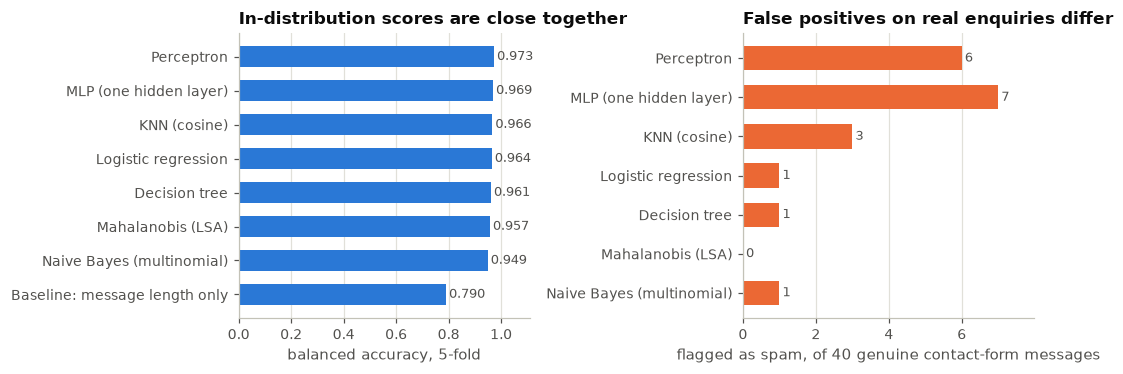

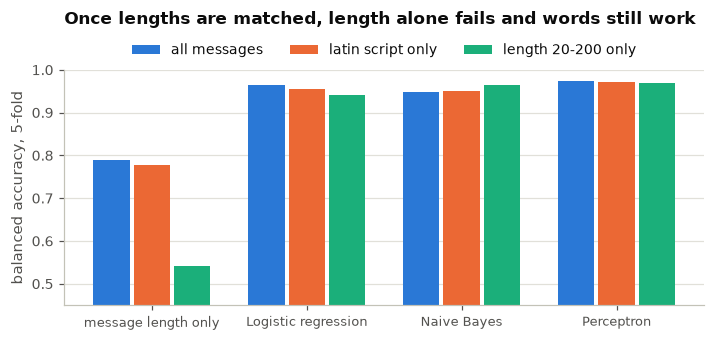

In [60]:
FP_COL = "contact-form legitimate flagged (false positives of 40)"
candidates_b = [m for m in LEARNED_B if m != "Mahalanobis (LSA)" and hasattr(MODELS_B[m], "predict_proba")
                and cv_b.loc[m, "size_kb"] < 5 * 1024 and cv_b.loc[m, "predict_ms"] < 10]
f1_b = cv_b.loc[candidates_b, "f1"].astype(float)
tied = [m for m in candidates_b if f1_b.max() - f1_b[m] <= 0.01]
selection = cross_tbl.loc[tied, [FP_COL, "same-source AUC"]].assign(cv_f1=f1_b[tied], cv_f1_std=cv_b.loc[tied, "f1_std"].astype(float))
selection = selection.sort_values([FP_COL, "same-source AUC"], ascending=[True, False])
CHOSEN = selection.index[0]
print("candidates with a probability output, within the size and speed limits:", candidates_b)
print(f"best F1 {f1_b.max():.4f} ({f1_b.idxmax()}); within 0.01 of it:")
display(selection)
print(f"chosen for the software: {CHOSEN}  ({cv_b.loc[CHOSEN, 'size_kb']:.0f} KB, {cv_b.loc[CHOSEN, 'predict_ms']:.3f} ms per message)")

holdout_text = holdout["text"].to_numpy(dtype=object)
thr_rows = []
for thr in [0.3, 0.5, 0.7, 0.9]:
    out = metrics_from_counts(*confusion_counts(yB, (oof_b[CHOSEN] >= thr).astype(int)))
    cs_pred = (fitted_cs[CHOSEN].predict_proba(cs_text)[:, 1] >= thr).astype(int)
    thr_rows.append({"threshold": thr, "precision": out["precision"], "recall": out["recall"], "specificity": out["specificity"],
                     "SMS spam caught": metrics_from_counts(*confusion_counts(cs_y, cs_pred))["recall"],
                     "contact-form legitimate flagged (of 40)": int((fitted_cs[CHOSEN].predict_proba(holdout_text)[:, 1] >= thr).sum())})
thr_tbl = pd.DataFrame(thr_rows)
print(f"{CHOSEN}: effect of the decision threshold (cross-validated scores for the first three columns)")
display(thr_tbl)

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.5))
order_b = cv_b.loc[LEARNED_B + ["Baseline: message length only"], "balanced_acc"].astype(float).sort_values(ascending=False)
barh(axes[0], order_b.index, order_b.values, fmt="{:.3f}", xlabel="balanced accuracy, 5-fold")
axes[0].set_title("In-distribution scores are close together")
fp40 = cross_tbl[FP_COL].reindex([m for m in order_b.index if m in cross_tbl.index])
barh(axes[1], fp40.index, fp40.values, color=C[1], fmt="{:.0f}", xlabel="flagged as spam, of 40 genuine contact-form messages")
axes[1].set_title("False positives on real enquiries differ")
savefig("fig_task_b_models")

fig, ax = plt.subplots(figsize=(6.6, 3.2))
sub_plot = subset_tbl.pivot(index="model", columns="subset", values="balanced_acc")[list(subsets)]
width = 0.26
for i, (sname, colour) in enumerate(zip(subsets, C)):
    ax.bar(np.arange(len(sub_plot)) + (i - 1) * width, sub_plot[sname], width=width * 0.9, color=colour, label=sname)
ax.set_xticks(np.arange(len(sub_plot)), [m.replace("Baseline: ", "").replace(" (multinomial)", "") for m in sub_plot.index], fontsize=8.5)
ax.set_ylim(0.45, 1.0)
ax.set_ylabel("balanced accuracy, 5-fold")
ax.grid(axis="x", visible=False)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3)
ax.set_title("Once lengths are matched, length alone fails and words still work", pad=30)
savefig("fig_task_b_controls")

METRICS["task_b"] = {
    "rows": int(len(yB)), "spam_share": float(yB.mean()),
    "cv": cv_b.reset_index().rename(columns={"index": "model"}).to_dict("records"),
    "alpha_scan": alpha_scan.to_dict("records"),
    "zero_frequency": {"never_in_legitimate": zero_in_ham, "never_in_spam": zero_in_spam, "vocabulary": int(len(vocab)),
                       "words_legitimate": int(totals[0]), "words_spam": int(totals[1])},
    "subset_checks": subset_tbl.to_dict("records"),
    "cross_source": cross_tbl.reset_index().to_dict("records"),
    "candidates": candidates_b, "tied_within_0.01_f1": tied, "chosen_model": CHOSEN,
    "thresholds": thr_rows,
    "spam_words": llr[frequent].sort_values(ascending=False).head(18).index.tolist(),
    "legitimate_words": llr[frequent].sort_values().head(18).index.tolist(),
}

## 9.6 Where the chosen model fails

In [61]:
chosen_fit = fitted_cs[CHOSEN]                       # the fit that never saw the held-out legitimate SMS
genuine = holdout.assign(spam_probability=chosen_fit.predict_proba(holdout_text)[:, 1])
print("genuine contact-form messages with the highest spam probability:")
display(genuine.sort_values("spam_probability", ascending=False).head(5)[["spam_probability", "text"]])

vectorizer_b, classifier_b = chosen_fit[0], chosen_fit[-1]
if hasattr(classifier_b, "coef_"):
    top_text = genuine.sort_values("spam_probability", ascending=False)["text"].iloc[0]
    contrib = pd.Series(vectorizer_b.transform([top_text]).multiply(classifier_b.coef_[0]).toarray().ravel(),
                        index=vectorizer_b.get_feature_names_out())
    print("words pushing the top message toward spam:      ", ", ".join(f"{w} ({v:+.2f})" for w, v in contrib.sort_values(ascending=False).head(6).items()))
    print("words pushing the top message toward legitimate:", ", ".join(f"{w} ({v:+.2f})" for w, v in contrib.sort_values().head(4).items()))

missed = (yB == 1) & (oof_pred_b[CHOSEN] == 0)
caught = (yB == 1) & (oof_pred_b[CHOSEN] == 1)
wrongly_flagged = (yB == 0) & (oof_pred_b[CHOSEN] == 1)
task_b_errors = {
    "spam passed as legitimate": int(missed.sum()), "legitimate flagged": int(wrongly_flagged.sum()),
    "median length, missed spam": float(np.median(lengths[missed])), "median length, caught spam": float(np.median(lengths[caught])),
    "missed spam with a URL": float(merged.loc[missed, "text"].str.contains("http", case=False).mean()),
    "caught spam with a URL": float(merged.loc[caught, "text"].str.contains("http", case=False).mean()),
    "script of missed spam": merged.loc[missed, "script"].value_counts().to_dict(),
}
print("\ncross-validation errors of the chosen model:")
for key, value in task_b_errors.items():
    print(f"   {key}: {value if not isinstance(value, float) else round(value, 2)}")
print("examples of missed spam:")
for text in merged.loc[missed, "text"].sample(6, random_state=SEED):
    print("   ", repr(text[:90]))
METRICS["task_b"]["errors"] = task_b_errors

genuine contact-form messages with the highest spam probability:


,spam_probability,text
13,0.607,"Hello, I would like a quotation for designing a five page company profile. We need it ..."
33,0.491,My project group wants to interview someone from your team for a course assignment. Wo...
0,0.467,"Hello, I saw your portfolio and I would like to ask whether you are available for a sm..."
39,0.446,"Hello, I enjoyed reading your tutorial on decision trees. One question, why did you us..."
26,0.381,I have a question about the data used in your recent blog post. Where did the figures ...


words pushing the top message toward spam:       hello (+0.43), page (+0.22), company (+0.21), profile (+0.19), for (+0.19), would (+0.16)
words pushing the top message toward legitimate: like (-0.19), it (-0.15), need (-0.09), two (-0.08)

cross-validation errors of the chosen model:
   spam passed as legitimate: 215
   legitimate flagged: 11
   median length, missed spam: 23.0
   median length, caught spam: 354.0
   missed spam with a URL: 0.11
   caught spam with a URL: 0.92
   script of missed spam: {'latin': 208, 'other': 4, 'cyrillic': 3}
examples of missed spam:
    'VOUqwNzgpAj'
    'Eshanti Silbereisen'
    'Hej, jeg ønskede at kende din pris.'
    'Niana Cuison'
    'Envee Glendon'
    'I saw your google, its not, well its not right.    Like where google show customers about '


**Analysis.**

- *The genuine message it flags* is a request for a quotation. Its words ("company", "page", "profile") are
  commerce words the model has only ever seen in spam, and even "hello" counts toward spam because SMS
  messages rarely start that way. This is the source difference again, visible in a single prediction.
- *The spam it misses is short.* Missed templates have a median length of about 23 characters against about
  350 for the caught ones, and only about one in ten contains a link. They are bare names, random strings and
  the one-line price enquiry in its many languages. A bag-of-words model has almost nothing to read in them.
- *The two defences share a blind spot.* These are the same senders that evade the honeypot (Sections 5 and
  7). What does identify them is their shape: short, no link, joined name. The association rules capture
  exactly that, which is why the scoring service reports the matched rules with every prediction. Adding
  shape features to the classifier is the obvious next step.

## 9.7 Summary of Task B

**Analysis of Task B.**

- **In-distribution scores are high and close.** Every word-based model reaches a balanced accuracy of about
  0.95 to 0.97, and the best AUC is above 0.99. On these numbers alone the task looks solved.
- **Much of that is the source difference.** Message length alone, with no words, already reaches a balanced
  accuracy near 0.79. The word lists say the same thing: the tokens that most indicate "spam" are URL
  fragments and Cyrillic words, and the tokens that most indicate "legitimate" are SMS slang. The models
  learned the difference between two collections at least as much as the difference between spam and
  non-spam.
- **Words still carry real signal.** Restricting both classes to 20-200 characters pushes the length baseline
  down to chance, while the word models keep a balanced accuracy of 0.94 or more. Removing non-Latin
  messages changes little.
- **The same-source test is the decisive one.** With SMS on both sides, the models still rank SMS spam above
  legitimate SMS (AUC well above 0.5 for most of them), so something about spam itself was learned. At the
  default threshold, though, most of them catch well under half of the SMS spam. The models know *form* spam;
  that knowledge transfers only partly to another kind of spam.
- **Higher in-distribution accuracy did not mean a better filter.** The perceptron and the MLP top the
  cross-validation table and also flag the most genuine contact-form messages. Naive Bayes, logistic
  regression and the decision tree flag almost none. The extra accuracy of the flexible models came from
  fitting the two collections more tightly.
- **Naive Bayes smoothing.** Most of the vocabulary never occurs in the legitimate class, so without smoothing
  almost every spam word would force a zero probability. Laplace smoothing (alpha = 1) fixes that but is not
  the best value here: the legitimate class is small, and adding one count for each of 17,000 vocabulary
  words flattens its word distribution. Smaller alpha values score higher.
- **Decision threshold.** The threshold table shows the trade-off for the chosen model; the software exposes
  the threshold as a setting.
- **Limits of this result.** The legitimate class is SMS, not real contact-form traffic, and the 40 genuine
  messages are synthetic. The scores describe this corpus. The model must be re-trained on the operator's own
  legitimate submissions once the form collects them.

# 10. Comparative evaluation: which algorithm suits which task

One table per classifier across both tasks, with the measures that matter for each: accuracy under drift for
Task A, and behaviour outside the training corpus for Task B.

In [62]:
ALIGN = {"Naive Bayes": "Naive Bayes (multinomial)", "Logistic regression": "Logistic regression",
         "Decision tree": "Decision tree", "KNN": "KNN (cosine)", "Mahalanobis (PCA)": "Mahalanobis (LSA)",
         "Perceptron": "Perceptron", "MLP (one hidden layer)": "MLP (one hidden layer)"}
summary = pd.DataFrame({
    "A: balanced acc, cross-validation": cv_a.loc[list(ALIGN), "balanced_acc"].astype(float).values,
    "A: balanced acc, future period": ts_a.loc[list(ALIGN), "balanced_acc"].astype(float).values,
    "A: AUC, future period": ts_a.loc[list(ALIGN), "auc"].astype(float).values,
    "B: balanced acc, cross-validation": cv_b.loc[list(ALIGN.values()), "balanced_acc"].astype(float).values,
    "B: same-source AUC": cross_tbl.loc[list(ALIGN.values()), "same-source AUC"].astype(float).values,
    "B: genuine messages flagged (of 40)": cross_tbl.loc[list(ALIGN.values()), FP_COL].astype(int).values,
    "B: model size (KB)": cv_b.loc[list(ALIGN.values()), "size_kb"].astype(float).round(0).values,
}, index=[n.replace(" (PCA)", "").replace(" (one hidden layer)", "") for n in ALIGN])
display(summary)
METRICS["summary"] = summary.reset_index().rename(columns={"index": "model"}).to_dict("records")

,"A: balanced acc, cross-validation","A: balanced acc, future period","A: AUC, future period","B: balanced acc, cross-validation",B: same-source AUC,B: genuine messages flagged (of 40),B: model size (KB)
Naive Bayes,0.779,0.492,0.472,0.949,0.768,1,1093.000
Logistic regression,0.791,0.689,0.765,0.964,0.912,1,821.000
Decision tree,0.734,0.539,0.628,0.961,0.464,1,693.000
KNN,0.783,0.570,0.557,0.966,0.690,3,2952.000
Mahalanobis,0.785,0.506,0.529,0.957,0.873,0,3414.000
Perceptron,0.789,0.560,0.570,0.973,0.828,6,821.000
MLP,0.775,0.513,0.587,0.969,0.920,7,3946.000


**Which algorithm for which job**

| Algorithm | Strength shown here | Weakness shown here | Verdict |
| --- | --- | --- | --- |
| Logistic regression | Best in Task A, in cross-validation and on future data; few false positives on genuine messages in Task B; probabilities; small, readable weights | Linear: cannot capture interactions between features | **Deployed** in the software |
| Naive Bayes | One pass to train; almost no false positives on genuine messages | Independence assumption is violated; needs the right variant and smoothing value; at chance on future data in Task A | Good fallback when no tuning is possible |
| Decision tree | Readable rules that match the Apriori findings | Lowest and least stable in Task A; poor ranking outside its corpus in Task B | Use for explanation, not for scoring |
| KNN | Competitive in cross-validation with no training step | Stores all data, slowest prediction, needs scaling, near chance on future data | Not suitable for a small server |
| Mahalanobis | Beats Euclidean nearest-mean by using covariance; no false positives on genuine messages in Task B | Needs PCA to be computable; at chance on future data in Task A | A teaching comparison; not deployed |
| Perceptron | Simplest neural unit, fast | No probabilities, weakest ranking in Task A, many false positives on genuine messages | Superseded by logistic regression |
| MLP | Near the top of the Task B cross-validation table | No better than the linear models in Task A, at chance on future data, flags the most genuine messages | Not justified at this data size |

Across both tasks the same pattern appears: scoring well on data drawn like the training data says little
about holding up when the data differs. The perceptron and the MLP lead the Task B cross-validation table and
flag the most genuine messages; most models that look fine in Task A cross-validation are at chance a year
later. Logistic regression is at or near the top in-distribution and clearly the most reliable outside it.
With a few thousand rows and a moving target, a simple probabilistic model is the right one.

# 11. Regression: is there a trend?

**What it is.** Linear regression fits `y = w0 + w1 x` by least squares; polynomial regression adds powers of
x. **Type of learning.** Supervised, with a numeric target.

**Why it is needed here.** Two operator questions are about trend: is spam volume growing, and is the honeypot
hit rate falling steadily? Both are checked with a fitted line and its R-squared.

**Implementation.** The slope and intercept come from the lecture formulas
`w1 = sum((x - mean_x)(y - mean_y)) / sum((x - mean_x)^2)`, `w0 = mean_y - w1 mean_x`, and the degree-2 fit
from the normal equation `W = (X^T X)^-1 X^T Y`. Both are checked against NumPy's least-squares fit.
Months missing from the export are left out, not counted as zero.

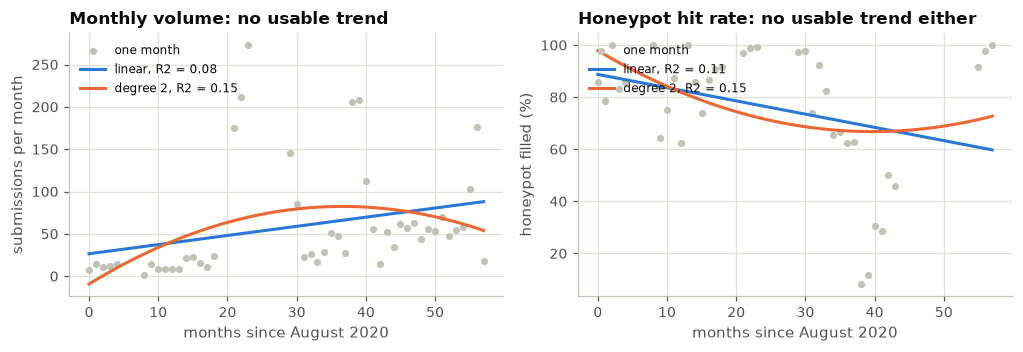

months with data: 48 of 58
            months w1_per_month r2_linear r2_degree2
submissions     48        1.080     0.084      0.154
hit_rate        37       -0.509     0.108      0.151


In [63]:
monthly = (fact.assign(month_start=fact["timestamp"].dt.to_period("M").dt.to_timestamp())
           .groupby("month_start").agg(submissions=("id", "size"), hit_rate=("honeypot_filled", "mean")).reset_index())
start = monthly["month_start"].min()
monthly["t"] = (monthly["month_start"].dt.year - start.year) * 12 + (monthly["month_start"].dt.month - start.month)


# ---- algorithms/regression.py ----
import numpy as np


def fit_line(x, y):
    w1 = float(((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean()) ** 2).sum())
    return float(y.mean() - w1 * x.mean()), w1


def fit_polynomial(x, y, degree):
    X = np.vander(x, degree + 1, increasing=True)            # columns 1, x, x^2, ...
    return np.linalg.inv(X.T @ X) @ X.T @ y                  # normal equation


def r_squared(y, y_hat):
    return float(1 - ((y - y_hat) ** 2).sum() / ((y - y.mean()) ** 2).sum())


trend = {}
grid_t = np.linspace(monthly["t"].min(), monthly["t"].max(), 200)
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.3))
for ax, col, ylabel, scale in [(axes[0], "submissions", "submissions per month", 1), (axes[1], "hit_rate", "honeypot filled (%)", 100)]:
    part = monthly.dropna(subset=[col])                      # months without a honeypot have no hit rate
    t, y = part["t"].to_numpy(dtype=float), part[col].to_numpy(dtype=float) * scale
    w0, w1 = fit_line(t, y)
    w_poly = fit_polynomial(t, y, 2)
    assert np.allclose([w1, w0], np.polyfit(t, y, 1)) and np.allclose(w_poly[::-1], np.polyfit(t, y, 2))
    r2_lin, r2_poly = r_squared(y, w0 + w1 * t), r_squared(y, np.vander(t, 3, increasing=True) @ w_poly)
    trend[col] = {"months": int(len(part)), "w0": w0, "w1_per_month": w1, "r2_linear": r2_lin,
                  "poly_coefficients": w_poly.tolist(), "r2_degree2": r2_poly}
    ax.scatter(t, y, s=22, color=GRAY, linewidths=0, label="one month")
    ax.plot(grid_t, w0 + w1 * grid_t, color=C[0], label=f"linear, R2 = {r2_lin:.2f}")
    ax.plot(grid_t, np.vander(grid_t, 3, increasing=True) @ w_poly, color=C[1], label=f"degree 2, R2 = {r2_poly:.2f}")
    ax.set_xlabel(f"months since {start:%B %Y}")
    ax.set_ylabel(ylabel)
    ax.legend(loc="upper left", fontsize=8)
axes[0].set_title("Monthly volume: no usable trend")
axes[1].set_title("Honeypot hit rate: no usable trend either")
savefig("fig_trend")
print(f"months with data: {len(monthly)} of {int(monthly['t'].max()) + 1}")
print(pd.DataFrame(trend).T[["months", "w1_per_month", "r2_linear", "r2_degree2"]])
METRICS["trend"] = {"months_with_data": int(len(monthly)), **trend}

**Analysis.** The hand formulas reproduce NumPy's fit exactly.

- *Volume.* A straight line explains under a tenth of the variance of monthly volume and a parabola not much
  more. Volume is driven by bursts, a campaign switching on and off, not by a smooth trend.
- *Hit rate.* The fitted line slopes down by about half a percentage point per month and explains about a
  tenth of the variance. The monthly hit rate jumps between near 100% and near 10% depending on which campaign
  is active (Section 7.4); it does not decline steadily.

Regression answers "is there a smooth trend?" with "no", for both quantities. Forecasting this form's spam
from a trend line would be wrong; the campaign view is the informative one.

Logistic regression, the classification member of the regression family, was applied in Sections 8 and 9,
including the hand calculation of the sigmoid for one row.

# 12. Export for the software and the paper

The chosen Task B model is re-fitted on all messages and saved, together with the campaign model
(vectorizer, LSA and K-means centroids), the campaign profiles, the association rules and every metric.

In [64]:
import joblib
import sklearn


def jsonable(obj):
    """Plain Python types only; NaN becomes null so that any JSON parser accepts the file."""
    if isinstance(obj, dict):
        return {str(k): jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [jsonable(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (float, np.floating)):
        return None if math.isnan(obj) or math.isinf(obj) else float(obj)
    if isinstance(obj, np.ndarray):
        return jsonable(obj.tolist())
    if isinstance(obj, (pd.Timestamp,)):
        return obj.isoformat()
    return obj


def dump(name, payload):
    with open(os.path.join(ART, name), "w", encoding="utf-8") as fh:
        json.dump(jsonable(payload), fh, ensure_ascii=False, indent=1)


spam_model = clone(MODELS_B[CHOSEN]).fit(textB, yB)
joblib.dump(spam_model, os.path.join(ART, "spam_model.joblib"))
joblib.dump({"vectorizer": tfidf_c, "lsa": lsa, "kmeans": kmeans}, os.path.join(ART, "campaign_model.joblib"))

medoid_examples = {int(km_on_sample[m]): ct["message"].iloc[med_idx[m]][:200] for m in medoids}
dump("clusters.json", {"k": K, "campaigns": campaigns.to_dict("records"), "medoid_examples": medoid_examples})
dump("rules.json", {
    "min_support": MIN_SUP, "min_confidence": MIN_CONF,
    "honeypot_filled": top_filled.to_dict("records"), "honeypot_empty": top_empty.to_dict("records"),
    "decision_tree_depth3": export_text(tree3, feature_names=FEATURES, decimals=2),
})
dump("model_card.json", {
    "model": CHOSEN, "trained_on_rows": int(len(yB)), "default_threshold": 0.5,
    "cv": cv_b.loc[CHOSEN, COLS].astype(float).to_dict(),
    "same_source_auc": float(cross_tbl.loc[CHOSEN, "same-source AUC"]),
    "genuine_messages_flagged_of_40": int(cross_tbl.loc[CHOSEN, FP_COL]),
    "thresholds": thr_rows, "sklearn_version": sklearn.__version__,
    "limits": "Legitimate class is public SMS, not real contact-form traffic. Re-train on the operator's own data.",
})
dump("metrics.json", METRICS)

for probe in ["Make $5000 a day with our financial robot http://example.com/robot",
              "Hello, I would like to ask about your office hours next week. Thank you."]:
    print(f"P(spam) = {spam_model.predict_proba(np.array([probe], dtype=object))[0, 1]:.3f}  <-  {probe}")
print("\nartifacts written to", os.path.abspath(ART))
for name in sorted(os.listdir(ART)):
    path = os.path.join(ART, name)
    print(f"   {name:<24} {'(folder)' if os.path.isdir(path) else f'{os.path.getsize(path) / 1024:,.0f} KB'}")

P(spam) = 0.969  <-  Make $5000 a day with our financial robot http://example.com/robot
P(spam) = 0.179  <-  Hello, I would like to ask about your office hours next week. Thank you.

artifacts written to D:\Study\DM - Project\artifacts
   campaign_model.joblib    4,817 KB
   clusters.json            11 KB
   figures                  (folder)
   metrics.json             54 KB
   model_card.json          1 KB
   rules.json               3 KB
   spam_model.joblib        946 KB


# Summary of findings

1. **The honeypot is not dependable.** Its hit rate was about 98% in 2022, about 10% in October and November
   2023, and above 90% again in spring 2025 (OLAP, Section 4).
2. **Checking the label mattered.** A run of 647 consecutive submissions over twelve months never fills the
   honeypot. The form had no honeypot field in that period; those rows were treated as unlabelled
   (Section 1.3). Trusting them would have changed the class balance and the model scores (Section 8.10).
3. **Honeypot behaviour belongs to the campaign.** One campaign fills every field and is always caught;
   another sends a one-line multilingual enquiry and is almost never caught (Apriori, Section 5; clustering,
   Section 7).
4. **Honeypot evasion is moderately predictable inside a period and poorly predictable forward.** Balanced
   accuracy of about 0.79 in cross-validation; on the following period only logistic regression stays clearly
   above chance, at about 0.69 (Section 8).
5. **Spam-versus-legitimate scores look excellent and are partly an artefact.** About 0.97 balanced accuracy
   in-distribution, of which message length alone explains a large part. Out-of-corpus checks, not the
   headline score, decided which model to deploy (Section 9).
6. **Simple, probabilistic and re-trainable beats flexible** at this data size and under this much change
   (Section 10).